# Measuring emission line fluxes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# read the data
import pandas as pd
galname = 'J1624'
j1624 = pd.read_csv(galname + '.csv')

wave = j1624['wave'].to_numpy()
flux = j1624['flux'].to_numpy() * 1e17
err = j1624['noise'].to_numpy() * 1e17
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# Main lines
        
# [NII]6548 + Ha + [NII]6584
select = (wave > 6740) * (wave < 6805)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# Hb + [OIII]4959 + [OIII]5007
select = (wave > 5150) * (wave < 5185)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])


# Low ionization lines

# [OII]7319 + [OII]7330
select = (wave > 7535) * (wave < 7580)
oii_7320 = SpecPiece('oii7330', wave[select], flux[select], err[select])

# [SII]6716 + [SII]6731
select = (wave > 6910) * (wave < 6960)
sii = SpecPiece('sii', wave[select], flux[select], err[select])

# [NII]5755
select = (wave > 5880) * (wave < 6000)
nii_5755 = SpecPiece('nii5755', wave[select], flux[select], err[select])

# Hb
select = (wave > 5000) * (wave < 5030)
hbeta = SpecPiece('hb', wave[select], flux[select], err[select])

# Hg
select = (wave > 4460) * (wave < 4495)
hgamma = SpecPiece('hg', wave[select], flux[select], err[select])

# Hd
select = (wave > 4210) * (wave < 4255)
hdelta = SpecPiece('hd', wave[select], flux[select], err[select])

# [SII]4068 + [SII]4076
select = (wave > 4180) * (wave < 4225)
sii2 = SpecPiece('sii2', wave[select], flux[select], err[select])

# [OII]3726 + [OII]3729
select = (wave > 3835) * (wave < 3855)
oii_3727 = SpecPiece('oii3727', wave[select], flux[select], err[select])


# High ionization lines

# [SIII]9532
select = (wave > 9780) * (wave < 9890)
siii_9532 = SpecPiece('siiia', wave[select], flux[select], err[select])

# [SIII]9069
select = (wave > 9300) * (wave < 9410)
siii_9069 = SpecPiece('siiib', wave[select], flux[select], err[select])

# [Ar III]7135
select = (wave > 7320) * (wave < 7400)
ariii_7135 = SpecPiece('ariii_7135', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 6465) * (wave < 6545)
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5090) * (wave < 5140)
oiii_4959 = SpecPiece('oiiib', wave[select], flux[select], err[select])

# HeII4686
select = (wave > 4800) * (wave < 4870)
heii_4686 = SpecPiece('heii4686', wave[select], flux[select], err[select])

# [OIII]4363
select = (wave > 4490) * (wave < 4515)
oiii_4363 = SpecPiece('oiiic', wave[select], flux[select], err[select])

# [NeIII]3868
select = (wave > 3970) * (wave < 4010)
neiii_3868 = SpecPiece('neiiia', wave[select], flux[select], err[select])

Text(0.5, 1.0, 'J1624')

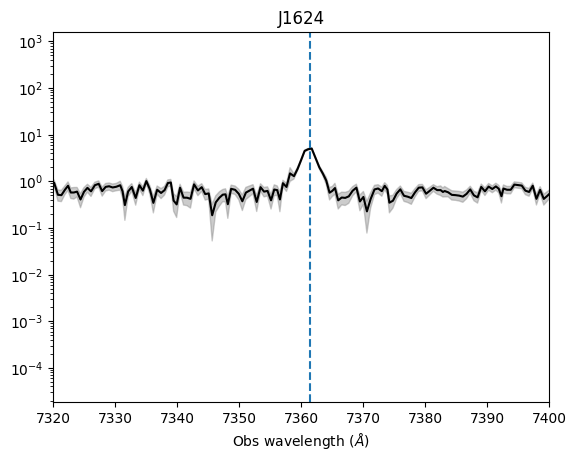

In [3]:
plt.plot(wave, flux, color='black')
plt.xlim(7320, 7400)
#plt.ylim(2e-18, 1e-16)
plt.fill_between(wave, flux-err, flux+err, color='gray', alpha=0.4)
plt.axvline((1 + z_BN[igal])*wave_cat['[ArIII]7135'], ls='--')
plt.yscale('log')
plt.xlabel('Obs wavelength ($\AA$)')
plt.title('J1624')
#plt.savefig('/home/benjamin/Documents/analogs/HeIIJ1624.pdf', bbox_inches='tight')

---

# Two component model fit for [OIII] 4959

# [OIII]4959

In [4]:
m = arc_slope23
n = arc_intercept23

sigma_arc_4959 = (m * wave_cat['[OIII]4959']*(1 + z_BN[igal])) + n

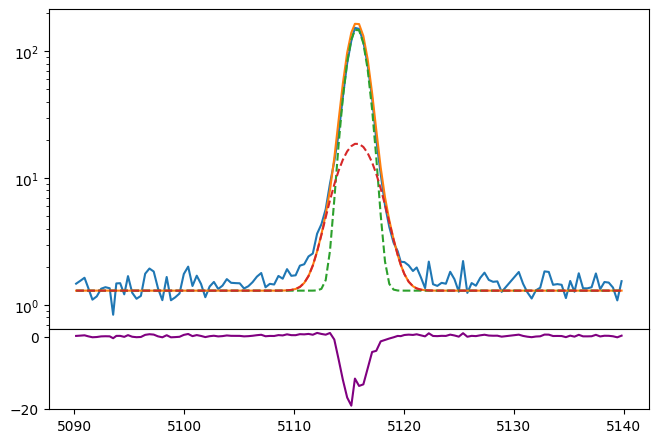

In [5]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 1.3

oiiib_nar = gaussian(oiii_4959.wavelength, 300, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=0.8)
oiiib_brd = gaussian(oiii_4959.wavelength, 70, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.6)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
ax.set_yscale('log')

In [6]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z_nar', value=z_BN[igal])
params_oiii_4959.add('z_brd', value=z_BN[igal])
params_oiii_4959.add('sigma_nar', value=0.8, min=0.)
params_oiii_4959.add('sigma_brd', value=1.6, min=0.)
params_oiii_4959.add('Oiiib_nar', value=300, min=0.)
params_oiii_4959.add('Oiiib_brd', value=70, min=0.)
params_oiii_4959.add('bkg', value=1.3, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z_nar = params_oiii_4959['z_nar']
    z_brd = params_oiii_4959['z_brd']
    sigma_nar = params_oiii_4959['sigma_nar']
    sigma_brd = params_oiii_4959['sigma_brd']
    oiiib_nar = params_oiii_4959['Oiiib_nar']
    oiiib_brd = params_oiii_4959['Oiiib_brd']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [7]:
np.random.seed(1624)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 130.60it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 44.05415188  52.87274818  41.65982271  96.67496759  61.05143559
  82.38043278 143.78692849]


In [8]:
out_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03162901,7.5716e-07,(0.00%),0.03162,-inf,inf,True
z_brd,0.03158413,5.3132e-06,(0.02%),0.03162,-inf,inf,True
sigma_nar,0.76003524,0.00560541,(0.74%),0.8,0.00000000,inf,True
sigma_brd,1.69723910,0.04485651,(2.64%),1.6,0.00000000,inf,True
Oiiib_nar,261.395992,3.69327014,(1.41%),300,0.00000000,inf,True
Oiiib_brd,66.5561263,3.49931518,(5.26%),70,0.00000000,inf,True
bkg,1.50296297,0.02016142,(1.34%),1.3,0.00000000,inf,True


In [9]:
np.random.seed(1624)
out2_oiii_4959 = minimize(residual_oiii_4959, out_oiii_4959.params, args=(1, 1, 1),
                      method='leastsq')

In [10]:
out2_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03162902,9.4888e-07,(0.00%),0.03162901072604161,-inf,inf,True
z_brd,0.03158436,6.3457e-06,(0.02%),0.03158413269009033,-inf,inf,True
sigma_nar,0.75966763,0.00667562,(0.88%),0.7600352431187024,0.00000000,inf,True
sigma_brd,1.69505135,0.05031441,(2.97%),1.6972390954799454,0.00000000,inf,True
Oiiib_nar,261.188064,4.29292648,(1.64%),261.39599214870066,0.00000000,inf,True
Oiiib_brd,66.7060563,4.05344701,(6.08%),66.55612629342659,0.00000000,inf,True
bkg,1.50357749,0.02620971,(1.74%),1.5029629653226113,0.00000000,inf,True


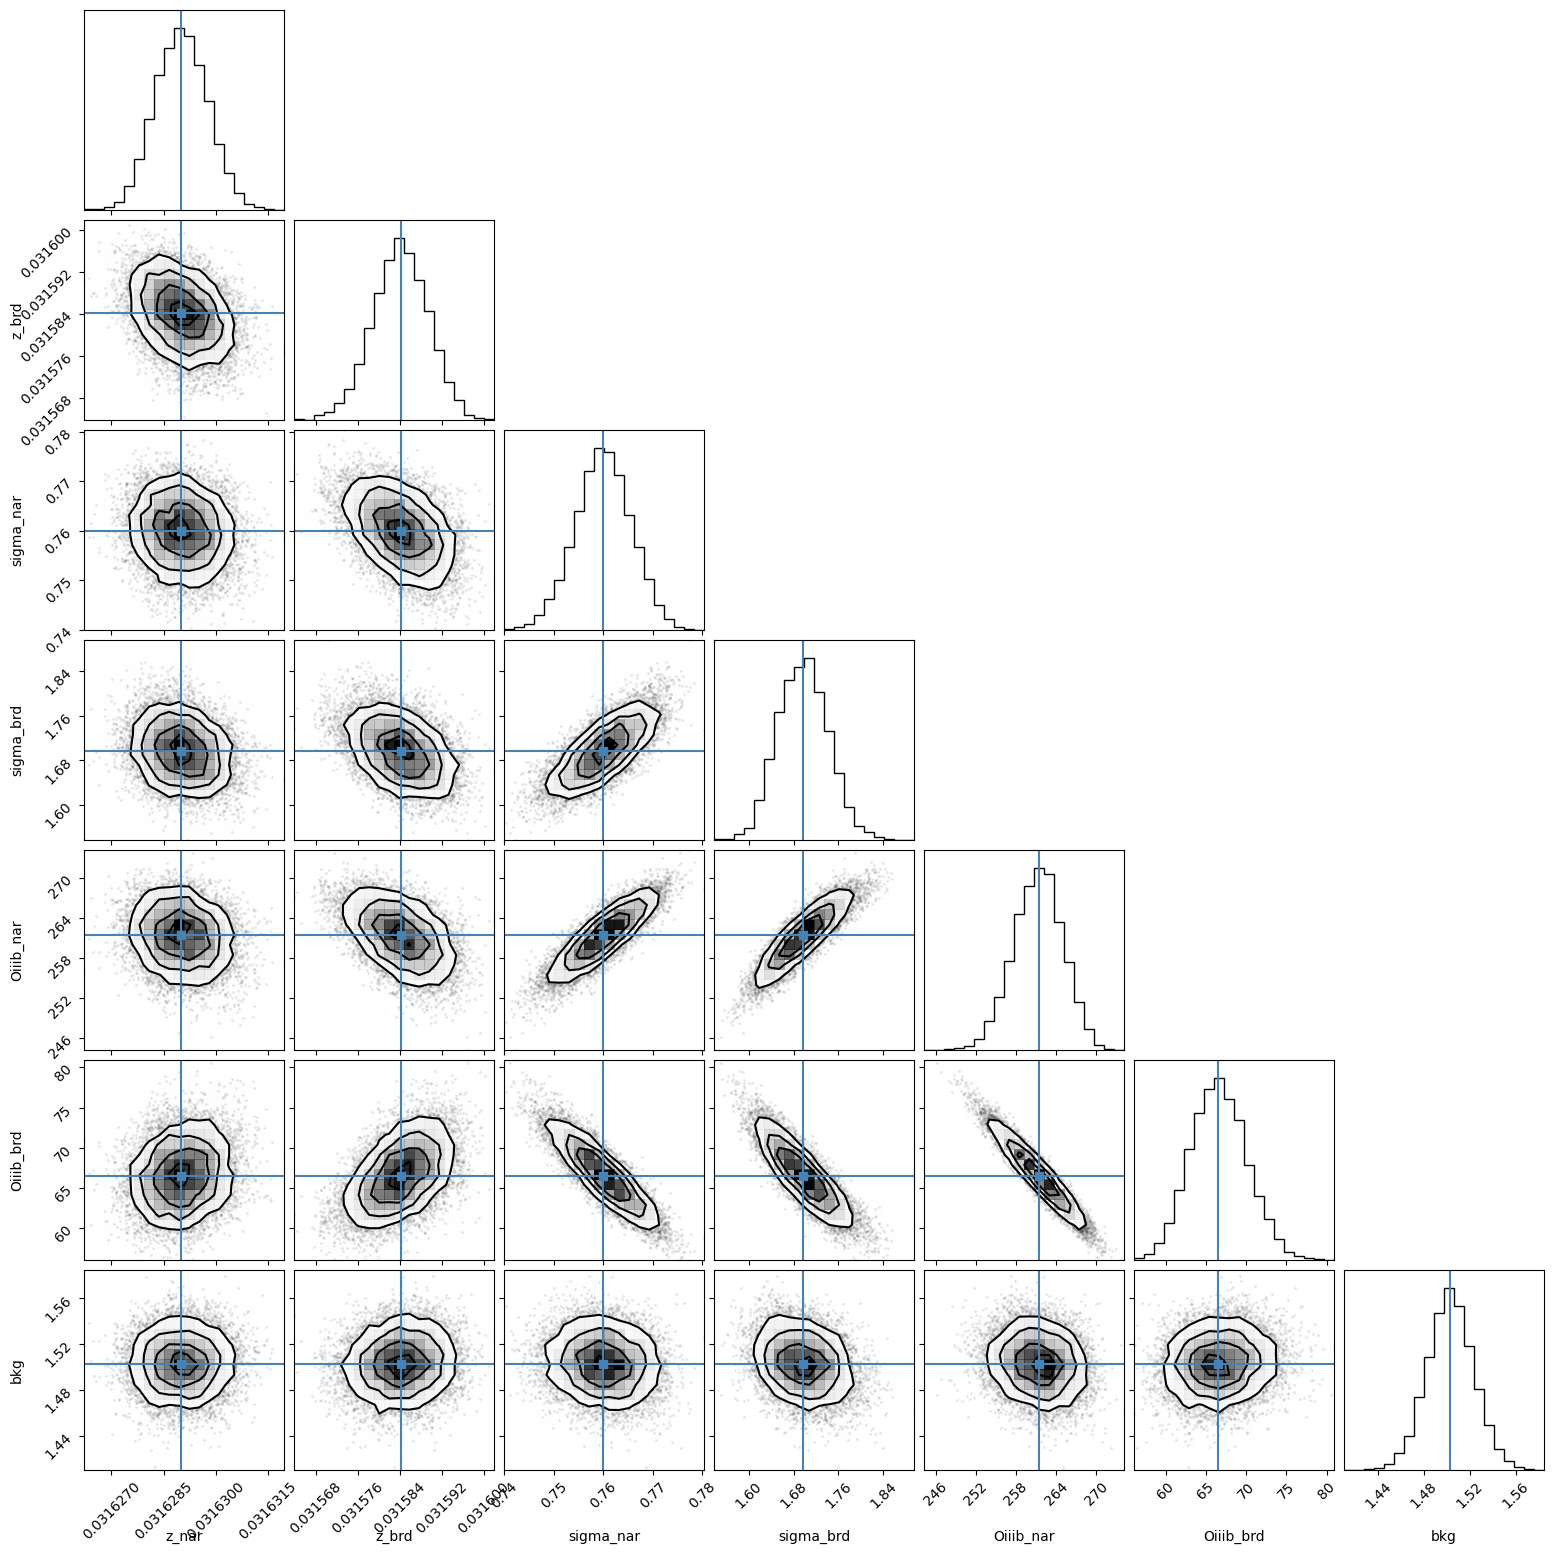

In [11]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names,
             truths=list(out_oiii_4959.params.valuesdict().values()));
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

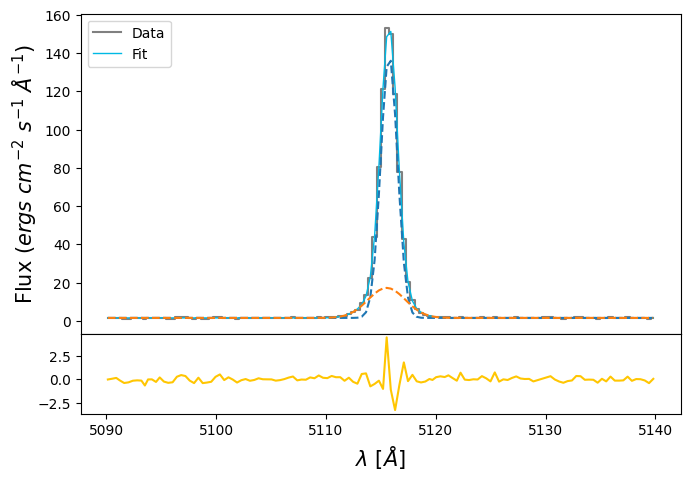

In [12]:
oiiib_nar_flux = out2_oiii_4959.params['Oiiib_nar'].value
oiiib_nar_std = out2_oiii_4959.params['Oiiib_nar'].stderr

oiiib_brd_flux = out2_oiii_4959.params['Oiiib_brd'].value
oiiib_brd_std = out2_oiii_4959.params['Oiiib_brd'].stderr

bkg_oiii_4959 = out2_oiii_4959.params['bkg'].value
bkg_oiii_4959_std = out2_oiii_4959.params['bkg'].stderr

z_nar_oiii_4959 = out2_oiii_4959.params['z_nar'].value
z_nar_oiii_4959_std = out2_oiii_4959.params['z_nar'].stderr

z_brd_oiii_4959 = out2_oiii_4959.params['z_brd'].value
z_brd_oiii_4959_std = out2_oiii_4959.params['z_brd'].stderr

sigma_nar_oiii_4959 = out2_oiii_4959.params['sigma_nar'].value
sigma_nar_oiii_4959_std = out2_oiii_4959.params['sigma_nar'].stderr

sigma_brd_oiii_4959 = out2_oiii_4959.params['sigma_brd'].value
sigma_brd_oiii_4959_std = out2_oiii_4959.params['sigma_brd'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.legend(loc='upper left')

In [13]:
# Correcting sigma by instrumental broadening

# Intrinsic from the galaxy
sigma_nar_intrinsic = upy.sqrt((ufloat(sigma_nar_oiii_4959, sigma_nar_oiii_4959_std)**2) - (sigma_arc_4959**2))
sigma_brd_intrinsic = upy.sqrt((ufloat(sigma_brd_oiii_4959, sigma_brd_oiii_4959_std)**2) - (sigma_arc_4959**2))

In [14]:
# EW
EW_OIII_4959_nar = ufloat(oiiib_nar_flux, oiiib_nar_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959_brd = ufloat(oiiib_brd_flux, oiiib_brd_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959 = (ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)

# FWHM
FWHM_4959_nar = FWHM(sigma_nar_intrinsic,  wave_cat['[OIII]4959']*(1 + ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))
FWHM_4959_brd = FWHM(sigma_brd_intrinsic,  wave_cat['[OIII]4959']*(1 + ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std)))

# velocity shift
dV_4959 = dV(ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std),
             ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std))

# Ratio to fix velocity shifts between components
z_ratio = z_brd_oiii_4959 / z_nar_oiii_4959

# Ratio to distribute the flux between components in no detection
brd_to_nar = oiiib_brd_flux / oiiib_nar_flux

# Dispersion for the whole spectra
dLam = (np.max(wave) - np.min(wave)) / len(wave)

In [15]:
print('Redshift of the narrow component: {:.4f}'.format(ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))

Redshift of the narrow component: 0.0316+/-0.0000


In [16]:
# Velocities
vel = {'galname': galname,
       'z_nar': z_nar_oiii_4959,
       'dV': dV_4959.nominal_value,
       'dV_err': dV_4959.std_dev,
       'FWHM_nar': FWHM_4959_nar.nominal_value,
       'FWHM_nar_err': FWHM_4959_nar.std_dev,
       'FWHM_brd': FWHM_4959_brd.nominal_value,
       'FWHM_brd_err': FWHM_4959_brd.std_dev
}
vel_catalog_pd = pd.DataFrame(data=vel, index=[0])
vel_catalog_pd

,galname,z_nar,dV,dV_err,FWHM_nar,FWHM_nar_err,FWHM_brd,FWHM_brd_err
0,J1624,0.031629,-12.979039,1.864553,79.554975,1.213061,223.668876,7.256745


In [17]:
save_catalog(galname, vel_catalog_pd, magePath + '/results/vel_catalog_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1624, overwriting...
Done.


---

# [NII]6548 + H$\alpha$ + [NII]6584

In [18]:
sigma_arc_ha = (m * wave_cat['Ha']*(1 + z_BN[igal])) + n

sigma_nar_ha = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_ha**2))
sigma_brd_ha = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_ha**2))

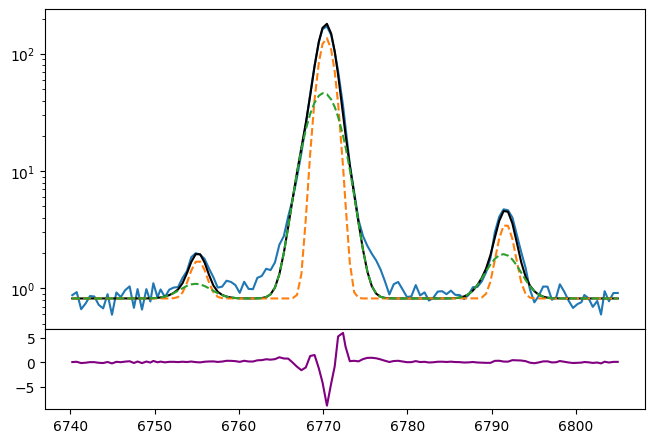

In [19]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)
bkg = 8.2e-1

ha_nar = gaussian(ha_nii.wavelength, 3e2, wave_cat['Ha'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, 2e2, wave_cat['Ha'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, 0.2e1, wave_cat['[NII]6548'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, 0.12e1, wave_cat['[NII]6548'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, 0.6e1, wave_cat['[NII]6584'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, 0.5e1, wave_cat['[NII]6584'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia, color='black')
ax.plot(ha_nii.wavelength, bkg + niib_nar + ha_nar + niia_nar, ls='--')
ax.plot(ha_nii.wavelength, bkg + niib_brd + ha_brd + niia_brd, ls='--')
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')
ax.set_yscale('log')

In [20]:
params_ha_nii = Parameters()
params_ha_nii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ha_nii.add('z_ratio', value=z_ratio, vary=False)
params_ha_nii.add('sigma_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('Ha_nar', value=3e2, min=0.)
params_ha_nii.add('Ha_brd', value=2e2, min=0.)
params_ha_nii.add('Niia_nar', value=0.6e1, min=0.)
params_ha_nii.add('Niia_brd', value=0.5e1, min=0.)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0., max=1.)
params_ha_nii.add('bkg', value=8.2e-1, vary=True)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z_nar = params_ha_nii['z_nar']
    z_brd = params_ha_nii['z_nar'] * params_ha_nii['z_ratio']
    sigma_nar = params_ha_nii['sigma_nar']
    sigma_brd = params_ha_nii['sigma_brd']
    ha_nar = params_ha_nii['Ha_nar']
    ha_brd = params_ha_nii['Ha_brd']
    niia_nar = params_ha_nii['Niia_nar']
    niia_brd = params_ha_nii['Niia_brd']
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    
    model_ha = gaussian(x, ha_nar, wave_cat['Ha'], z_nar, sigma_nar) \
             + gaussian(x, ha_brd, wave_cat['Ha'], z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, wave_cat['[NII]6584'], z_nar, sigma_nar) \
               + gaussian(x, niia_brd, wave_cat['[NII]6584'], z_brd, sigma_brd)
    
    model_niib = gaussian(x, niib_nar, wave_cat['[NII]6548'], z_nar, sigma_nar) \
               + gaussian(x, niib_brd, wave_cat['[NII]6548'], z_brd, sigma_brd)
    model = model_niib + model_ha + model_niia
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [21]:
np.random.seed(1226)
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:36<00:00, 68.45it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 68.38796983  87.03916698  96.49569738  74.35740677  62.94842422
 107.51280464  95.81172924]


In [22]:
out_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03163274,4.0716e-07,(0.00%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.87867323,,,0.8786732284944979,-inf,inf,False
sigma_brd,1.75161948,,,1.751619479733004,-inf,inf,False
Ha_nar,283.657652,1.32052957,(0.47%),300.0,0.00000000,inf,True
Ha_brd,211.556339,1.41400744,(0.67%),200.0,0.00000000,inf,True
Niia_nar,6.95584951,0.31446154,(4.52%),6.0,0.00000000,inf,True
Niia_brd,4.23033153,0.41599523,(9.83%),5.0,0.00000000,inf,True
Niib_to_niia,0.27833460,0.01508788,(5.42%),0.3333333333333333,0.00000000,1.00000000,True
bkg,0.93108247,0.01042113,(1.12%),0.82,-inf,inf,True


In [23]:
np.random.seed(1226)
out2_ha_nii = minimize(residual_ha_nii, out_ha_nii.params, args=(1, 1, 1),
                      method='leastsq')

In [24]:
out2_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03163274,1.1579e-06,(0.00%),0.03163273694688525,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.87867323,0.00000000,(0.00%),0.8786732284944979,-inf,inf,False
sigma_brd,1.75161948,0.00000000,(0.00%),1.751619479733004,-inf,inf,False
Ha_nar,283.591132,3.81872259,(1.35%),283.6576515461225,0.00000000,inf,True
Ha_brd,211.608257,3.98170275,(1.88%),211.55633927916347,0.00000000,inf,True
Niia_nar,6.96059486,0.91164031,(13.10%),6.955849509222472,0.00000000,inf,True
Niia_brd,4.24898879,1.20475610,(28.35%),4.230331527568471,0.00000000,inf,True
Niib_to_niia,0.27767816,0.04463847,(16.08%),0.27833459552924317,0.00000000,1.00000000,True
bkg,0.93058010,0.02965506,(3.19%),0.9310824654006193,-inf,inf,True


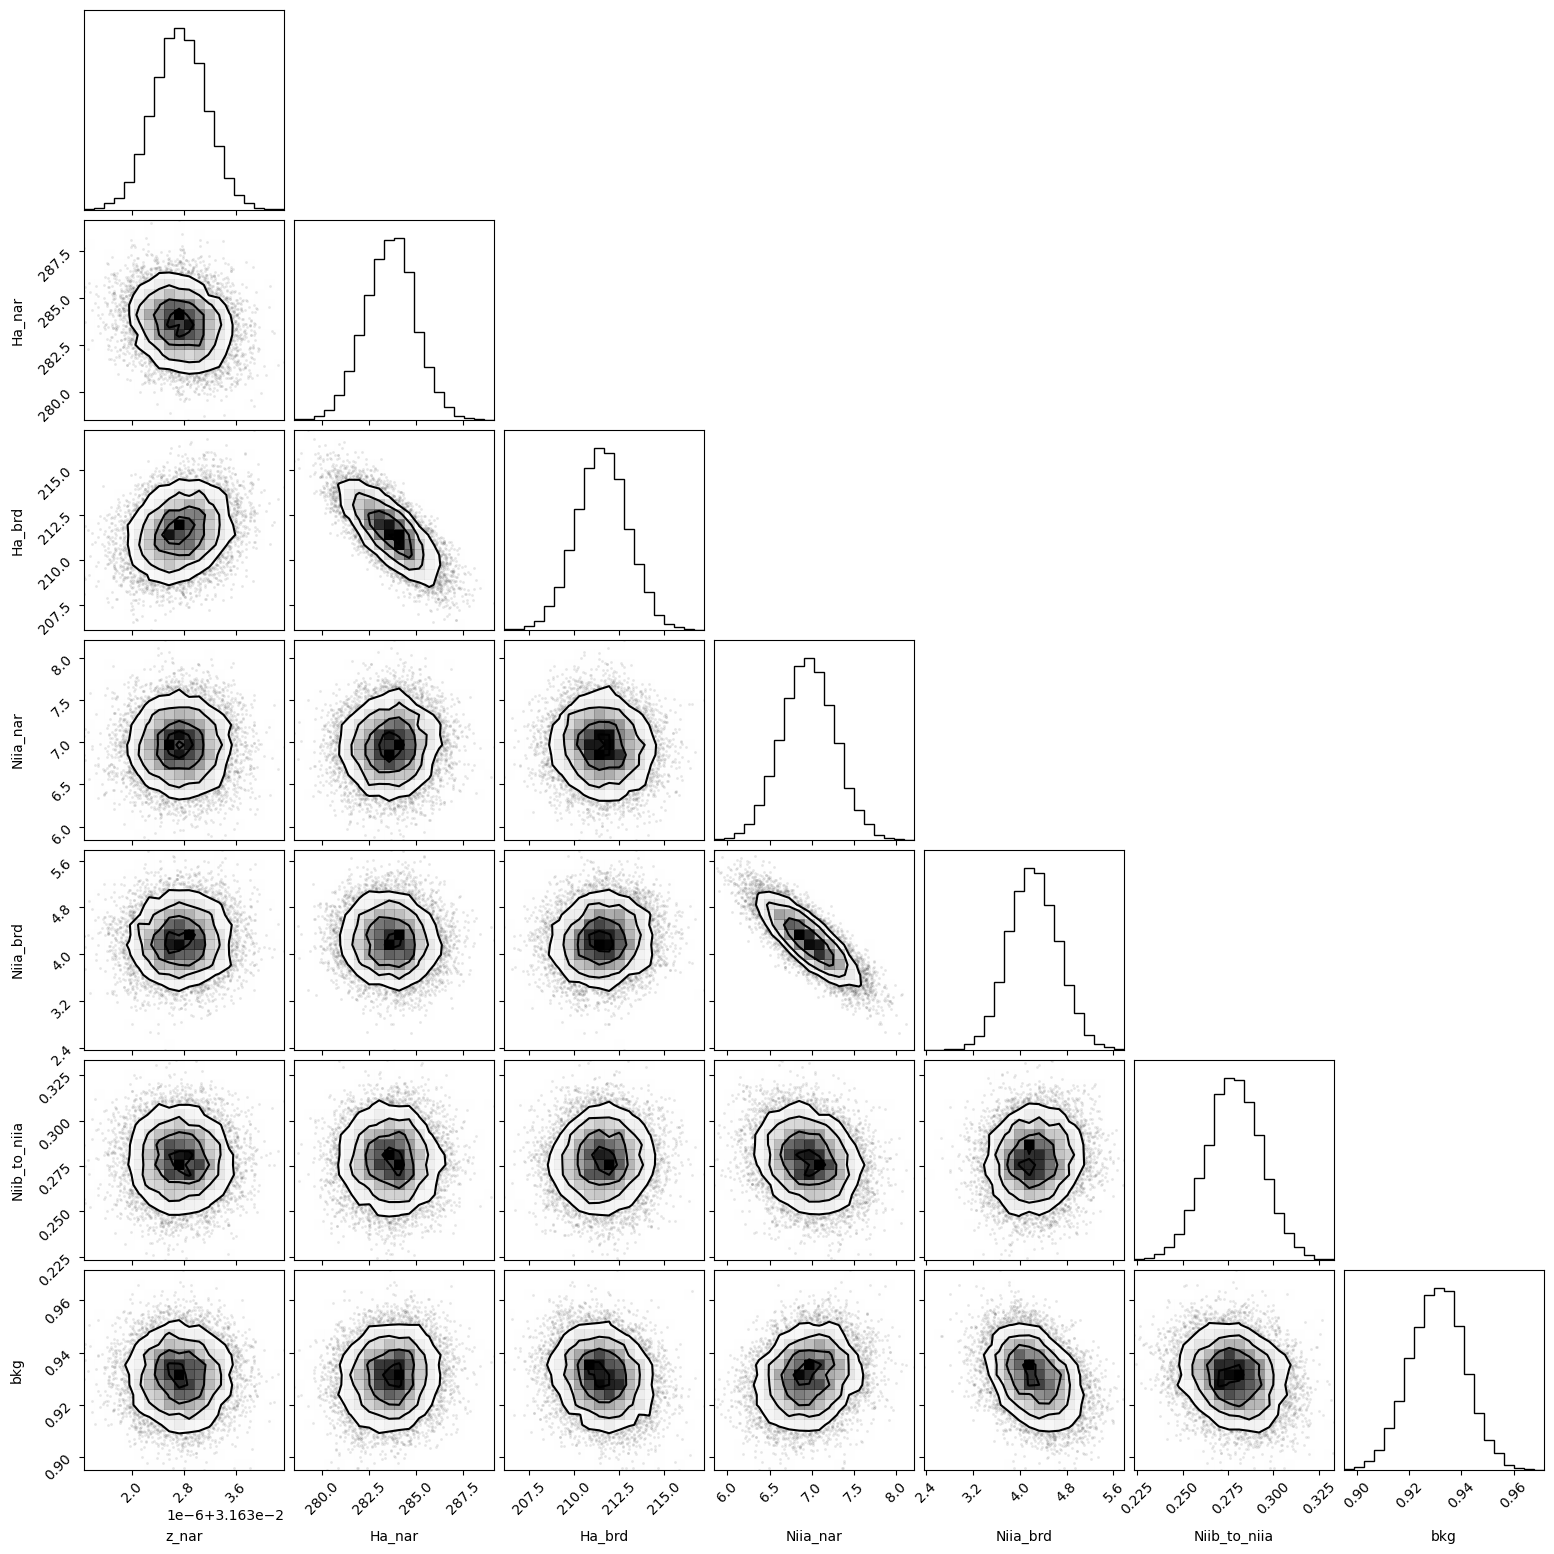

In [25]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

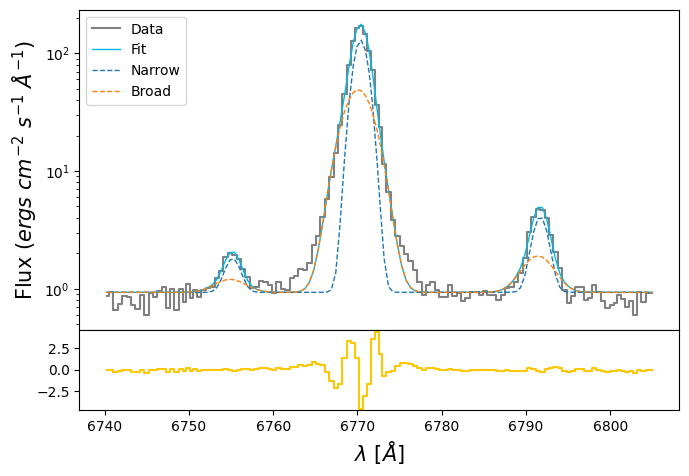

In [26]:
ha_nar_flux = out2_ha_nii.params['Ha_nar'].value
ha_nar_std = out2_ha_nii.params['Ha_nar'].stderr

ha_brd_flux = out2_ha_nii.params['Ha_brd'].value
ha_brd_std = out2_ha_nii.params['Ha_brd'].stderr

niia_nar_flux = out2_ha_nii.params['Niia_nar'].value
niia_nar_std = out2_ha_nii.params['Niia_nar'].stderr

niia_brd_flux = out2_ha_nii.params['Niia_brd'].value
niia_brd_std = out2_ha_nii.params['Niia_brd'].stderr

niib_nar_flux = niia_nar_flux * out_ha_nii.params['Niib_to_niia'].value
niib_nar_std = niia_nar_flux * out_ha_nii.params['Niib_to_niia'].stderr

niib_brd_flux = niia_brd_flux * out_ha_nii.params['Niib_to_niia'].value
niib_brd_std = niia_brd_flux * out_ha_nii.params['Niib_to_niia'].stderr

z_ha_nii = out_ha_nii.params['z_nar'].value
z_ha_nii_std = out_ha_nii.params['z_nar'].stderr

bkg_ha_nii = out_ha_nii.params['bkg'].value
bkg_ha_nii_std = out_ha_nii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data', where='mid')

ha_nar = gaussian(ha_nii.wavelength, ha_nar_flux, wave_cat['Ha'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, ha_brd_flux, wave_cat['Ha'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, niia_nar_flux, wave_cat['[NII]6584'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, niia_brd_flux, wave_cat['[NII]6584'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, niib_nar_flux, wave_cat['[NII]6548'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, niib_brd_flux, wave_cat['[NII]6548'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia = niia_nar + niia_brd
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia + ha + niib,
        lw=1, color=c[0], label='Fit')

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_nar + ha_nar + niib_nar,
        ls='--', lw=1, label='Narrow')
ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_brd + ha_brd + niib_brd,
        ls='--', lw=1, label='Broad')

ax1.step(ha_nii.wavelength, ha_nii.flux - bkg_ha_nii - niia - ha - niib,
         color=c[3], where='mid')
ax1.set_ylim(-5*bkg_ha_nii, 5*bkg_ha_nii)
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [27]:
# EW
EW_Ha_nar = ufloat(ha_nar_flux, ha_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha_brd = ufloat(ha_brd_flux, ha_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha = (ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6584_nar = ufloat(niia_nar_flux, niia_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584_brd = ufloat(niia_brd_flux, niia_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584 = (ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6548_nar = ufloat(niib_nar_flux, niib_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548_brd = ufloat(niib_brd_flux, niib_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548 = (ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

# [OII]7319 + [OII]7330

In [28]:
sigma_arc_7330 = (m * wave_cat['[OII]7330']*(1 + z_BN[igal])) + n

sigma_nar_7330 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7330**2))
sigma_brd_7330 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7330**2))

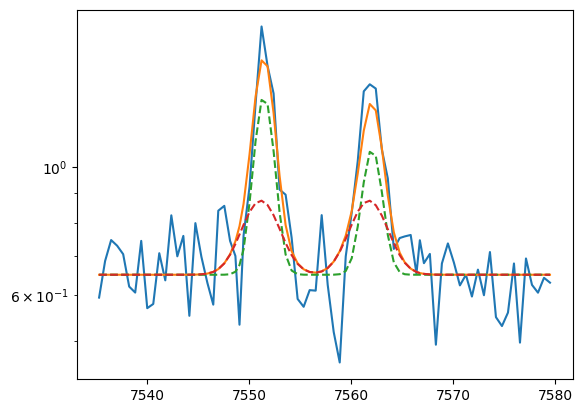

In [29]:
# Search for good initial guess

plt.plot(oii_7320.wavelength, oii_7320.flux)

oiia_nar = gaussian(oii_7320.wavelength, 1, wave_cat['[OII]7330'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiia_brd = gaussian(oii_7320.wavelength, 1, wave_cat['[OII]7330'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiib_nar = gaussian(oii_7320.wavelength, 1.6, wave_cat['[OII]7319'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiib_brd = gaussian(oii_7320.wavelength, 1, wave_cat['[OII]7319'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd
bkg = 6.5e-1

plt.plot(oii_7320.wavelength, bkg + oiib + oiia)
plt.plot(oii_7320.wavelength, bkg + oiib_nar + oiia_nar, ls='--')
plt.plot(oii_7320.wavelength, bkg + oiib_brd + oiia_brd, ls='--')

plt.yscale('log')

In [30]:
params_oii_7320 = Parameters()

params_oii_7320.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_7320.add('z_ratio', value=z_ratio, vary=False)
params_oii_7320.add('sigma_nar', value=upy.nominal_values(sigma_nar_7330), vary=False)
params_oii_7320.add('sigma_brd', value=upy.nominal_values(sigma_brd_7330), vary=False)
params_oii_7320.add('Oiia_nar', value=1.0, min=0.)
params_oii_7320.add('Oiia_brd', value=0., vary=False)
params_oii_7320.add('Oiib_nar', value=1.6, min=0.)
params_oii_7320.add('Oiib_brd', value=0., vary=False)
params_oii_7320.add('bkg', value=6.5e-1, min=0.)

def residual_oii_7320(params_oii_7320, x, data, uncertainty):
    
    z_nar = params_oii_7320['z_nar']
    z_brd = params_oii_7320['z_nar'] * params_oii_7320['z_ratio']
    sigma_nar = params_oii_7320['sigma_nar']
    sigma_brd = params_oii_7320['sigma_brd']
    oiia_nar_flux = params_oii_7320['Oiia_nar']
    oiia_brd_flux = params_oii_7320['Oiia_brd']
    oiib_nar_flux = params_oii_7320['Oiib_nar']
    oiib_brd_flux = params_oii_7320['Oiib_brd']
    bkg = params_oii_7320['bkg']
    
    x = oii_7320.wavelength
    model_oiia = gaussian(x, oiia_nar_flux, wave_cat['[OII]7330'], z_nar, sigma_nar) + \
                 gaussian(x, oiia_brd_flux, wave_cat['[OII]7330'], z_brd, sigma_brd)
    model_oiib = gaussian(x, oiib_nar_flux, wave_cat['[OII]7319'], z_nar, sigma_nar) + \
                 gaussian(x, oiib_brd_flux, wave_cat['[OII]7319'], z_brd, sigma_brd)
    model = model_oiia + model_oiib
    return (model + bkg - oii_7320.flux) / oii_7320.noise

In [31]:
np.random.seed(1624)
out_oii_7320 = minimize(residual_oii_7320, params_oii_7320, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:30<00:00, 83.14it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [40.75815229 55.99808006 47.48939542 41.24645049]


In [32]:
out_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03162555,8.8590e-06,(0.03%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.94097151,,,0.9409715069395856,-inf,inf,False
sigma_brd,1.78368482,,,1.7836848197423585,-inf,inf,False
Oiia_nar,1.91712756,0.14710591,(7.67%),1.0,0.00000000,inf,True
Oiia_brd,0.00000000,,,0.0,-inf,inf,False
Oiib_nar,2.34998992,0.15578834,(6.63%),1.6,0.00000000,inf,True
Oiib_brd,0.00000000,,,0.0,-inf,inf,False
bkg,0.66132444,0.01123090,(1.70%),0.65,0.00000000,inf,True


In [33]:
np.random.seed(1624)
out2_oii_7320 = minimize(residual_oii_7320, out_oii_7320.params, args=(1, 1, 1),
                         method='leastsq')

In [34]:
out2_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03162557,8.0863e-06,(0.03%),0.03162554850612426,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.94097151,0.00000000,(0.00%),0.9409715069395856,-inf,inf,False
sigma_brd,1.78368482,0.00000000,(0.00%),1.7836848197423585,-inf,inf,False
Oiia_nar,1.92644884,0.14201060,(7.37%),1.9171275560695609,0.00000000,inf,True
Oiia_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
Oiib_nar,2.35904563,0.14816380,(6.28%),2.349989921276973,0.00000000,inf,True
Oiib_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,0.66130012,0.01097657,(1.66%),0.661324443067263,0.00000000,inf,True


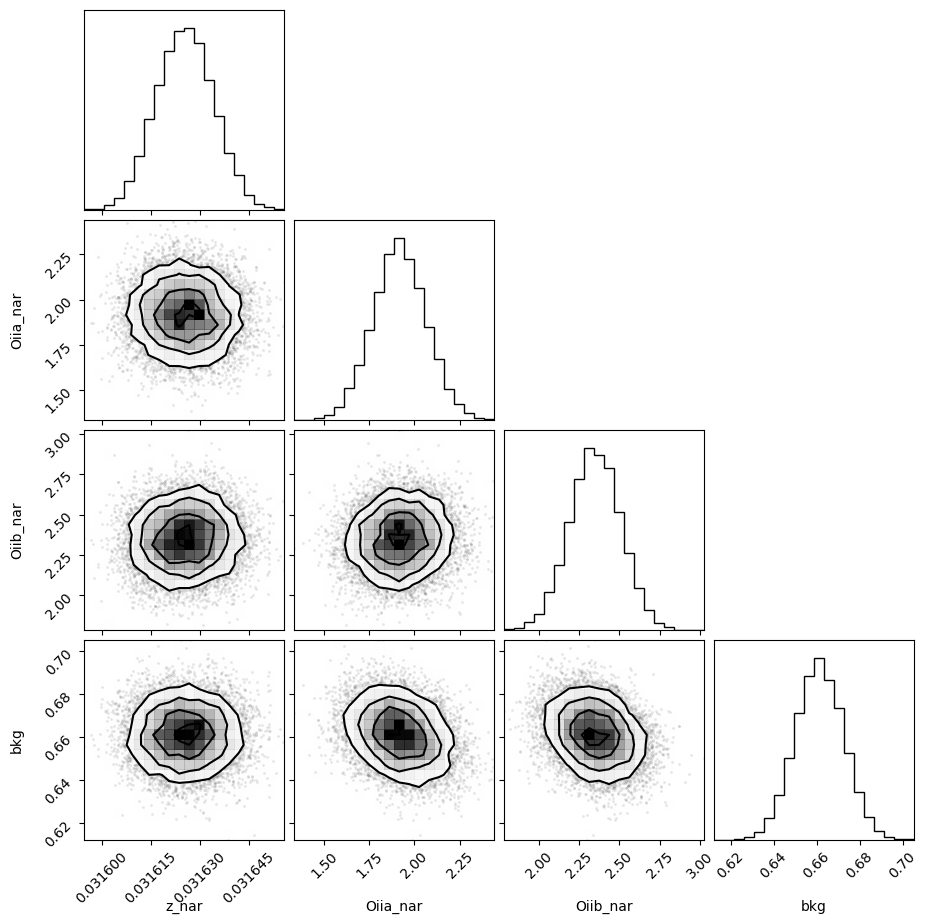

In [35]:
corner.corner(out_oii_7320.flatchain, labels=out_oii_7320.var_names);

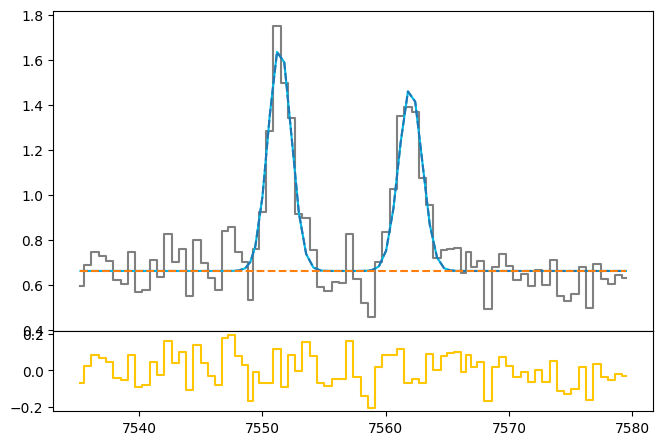

In [36]:
oiia_nar_flux = out2_oii_7320.params['Oiia_nar'].value
oiia_nar_std = out2_oii_7320.params['Oiia_nar'].stderr

oiia_brd_flux = out2_oii_7320.params['Oiia_brd'].value
oiia_brd_std = out2_oii_7320.params['Oiia_brd'].stderr

oiib_nar_flux = out2_oii_7320.params['Oiib_nar'].value
oiib_nar_std = out2_oii_7320.params['Oiib_nar'].stderr

oiib_brd_flux = out2_oii_7320.params['Oiib_brd'].value
oiib_brd_std = out2_oii_7320.params['Oiib_brd'].stderr

z_oii_7320 = out2_oii_7320.params['z_nar'].value
z_oii_7320_std = out2_oii_7320.params['z_nar'].stderr

bkg_oii_7320 = out2_oii_7320.params['bkg'].value
bkg_oii_7320_std = out2_oii_7320.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_7320.wavelength, oii_7320.flux, color='gray', label='Data', where='mid')

oiia_nar = gaussian(oii_7320.wavelength, oiia_nar_flux, wave_cat['[OII]7330'], z_oii_7320, upy.nominal_values(sigma_nar_7330))
oiib_nar = gaussian(oii_7320.wavelength, oiib_nar_flux, wave_cat['[OII]7319'], z_oii_7320, upy.nominal_values(sigma_nar_7330))

oiia_brd = gaussian(oii_7320.wavelength, oiia_brd_flux, wave_cat['[OII]7330'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))
oiib_brd = gaussian(oii_7320.wavelength, oiib_brd_flux, wave_cat['[OII]7319'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia + oiib, color=c[0])
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_nar + oiib_nar, ls='--')
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_brd + oiib_brd, ls='--')
#plt.yscale('log')
ax1.step(oii_7320.wavelength, oii_7320.flux - bkg_oii_7320 - oiia - oiib, color=c[3], where='mid')

In [37]:
# EW
EW_OII_7330_nar = ufloat(oiia_nar_flux, oiia_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330_brd = ufloat(oiia_brd_flux, oiia_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330 = (ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

EW_OII_7319_nar = ufloat(oiib_nar_flux, oiib_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319_brd = ufloat(oiib_brd_flux, oiib_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319 = (ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

# [SII]6716 + [SII]6730

In [38]:
sigma_arc_6730 = (m * wave_cat['[SII]6730']*(1 + z_BN[igal])) + n

sigma_nar_6730 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6730**2))
sigma_brd_6730 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6730**2))

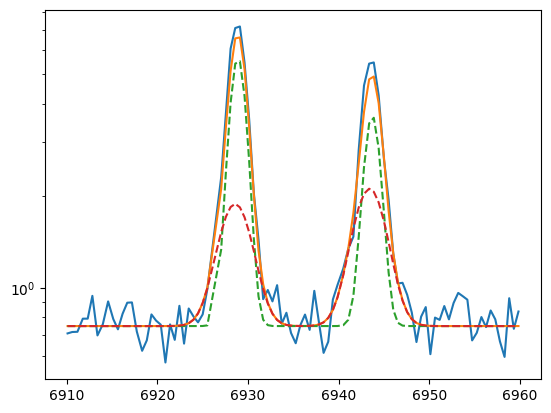

In [39]:
plt.plot(sii.wavelength, sii.flux)
bkg = 7.5e-1

siia_nar = gaussian(sii.wavelength, 6.5, wave_cat['[SII]6730'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siia_brd = gaussian(sii.wavelength, 6, wave_cat['[SII]6730'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siib_nar = gaussian(sii.wavelength, 1.1e1, wave_cat['[SII]6716'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siib_brd = gaussian(sii.wavelength, 5, wave_cat['[SII]6716'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

plt.plot(sii.wavelength, siia + siib + bkg)
plt.plot(sii.wavelength, siia_nar + siib_nar + bkg, ls='--')
plt.plot(sii.wavelength, siia_brd + siib_brd + bkg, ls='--')
plt.yscale('log')

In [40]:
params_sii = Parameters()
params_sii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_sii.add('z_ratio', value=z_ratio, vary=False)
params_sii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6730), vary=False)
params_sii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6730), vary=False)
params_sii.add('Siia_nar', value=6.5, min=0.)
params_sii.add('Siia_brd', value=6.0, min=0.)
params_sii.add('Siib_nar', value=1.1e1, min=0.)
params_sii.add('Siib_brd', value=5.0, min=0.)
params_sii.add('bkg', value=7.5e-1, min=0.)


def residual_sii(params_sii, x, data, uncertainty):
    
    z_nar = params_sii['z_nar']
    z_brd = params_sii['z_nar'] * params_sii['z_ratio']
    sigma_nar = params_sii['sigma_nar']
    sigma_brd = params_sii['sigma_brd']
    siia_nar_flux = params_sii['Siia_nar']
    siia_brd_flux = params_sii['Siia_brd']
    siib_nar_flux = params_sii['Siib_nar']
    siib_brd_flux = params_sii['Siib_brd']
    bkg = params_sii['bkg']
    
    x = sii.wavelength
    model_siia = gaussian(x, siia_nar_flux, wave_cat['[SII]6730'], z_nar, sigma_nar) + \
                 gaussian(x, siia_brd_flux, wave_cat['[SII]6730'], z_brd, sigma_brd)
    model_siib = gaussian(x, siib_nar_flux, wave_cat['[SII]6716'], z_nar, sigma_nar) + \
                 gaussian(x, siib_brd_flux, wave_cat['[SII]6716'], z_brd, sigma_brd)
    model = model_siia + model_siib
    return (model + bkg - sii.flux) / sii.noise

In [41]:
np.random.seed(1624)
out_sii = minimize(residual_sii, params_sii, args=(1, 1, 1),
                    method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:36<00:00, 67.95it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [51.57428657 75.64984863 59.66558295 51.73768991 49.58240125 48.58166768]


In [42]:
out_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03162074,2.0548e-06,(0.01%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.89206302,,,0.892063023870567,-inf,inf,False
sigma_brd,1.75837442,,,1.7583744191338417,-inf,inf,False
Siia_nar,8.38350317,0.36055906,(4.30%),6.5,0.00000000,inf,True
Siia_brd,5.18853907,0.47056238,(9.07%),6.0,0.00000000,inf,True
Siib_nar,12.4413281,0.44448335,(3.57%),11.0,0.00000000,inf,True
Siib_brd,5.09140725,0.60293991,(11.84%),5.0,0.00000000,inf,True
bkg,0.77583669,0.01129346,(1.46%),0.75,0.00000000,inf,True


In [43]:
np.random.seed(1624)
out2_sii = minimize(residual_sii, out_sii.params, args=(1, 1, 1),
                    method='leastsq')

In [44]:
out2_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03162083,2.2773e-06,(0.01%),0.03162074119950554,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.89206302,0.00000000,(0.00%),0.892063023870567,-inf,inf,False
sigma_brd,1.75837442,0.00000000,(0.00%),1.7583744191338417,-inf,inf,False
Siia_nar,8.38833803,0.40202414,(4.79%),8.383503165824347,0.00000000,inf,True
Siia_brd,5.19313239,0.51954871,(10.00%),5.188539067392116,0.00000000,inf,True
Siib_nar,12.4268644,0.49451984,(3.98%),12.441328106436524,0.00000000,inf,True
Siib_brd,5.10390655,0.66726170,(13.07%),5.0914072478656305,0.00000000,inf,True
bkg,0.77596931,0.01255347,(1.62%),0.7758366925850388,0.00000000,inf,True


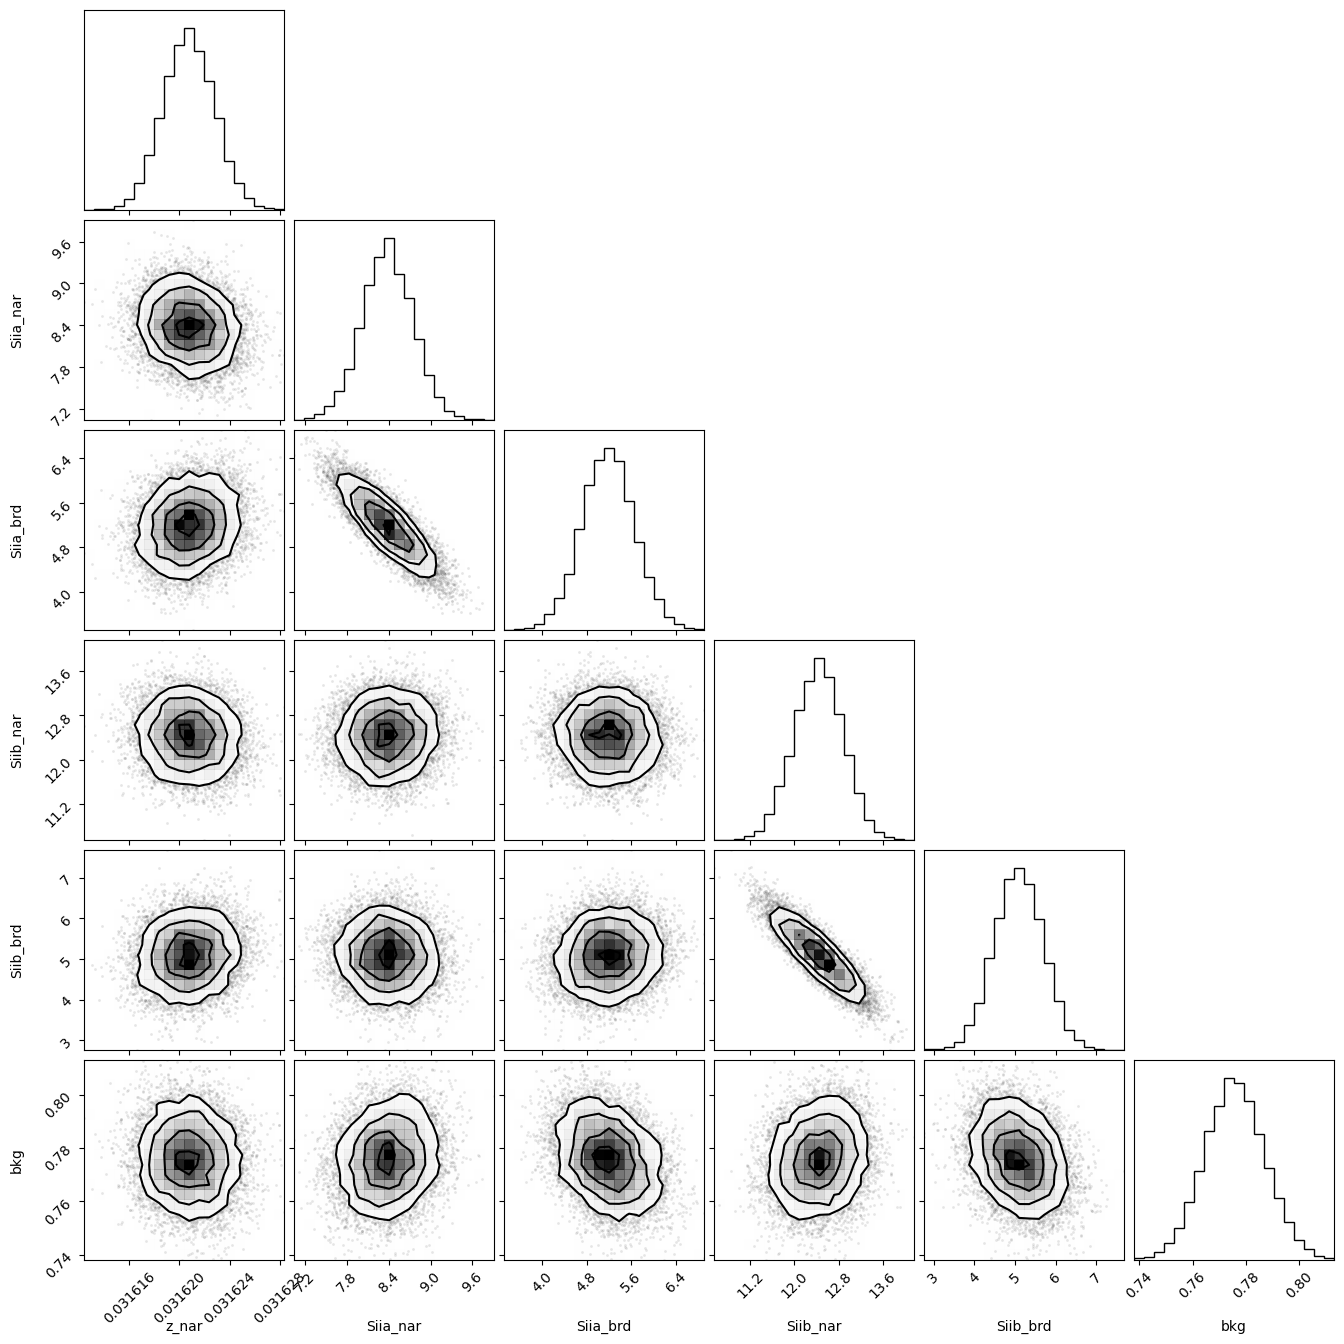

In [45]:
corner.corner(out_sii.flatchain, labels=out_sii.var_names);

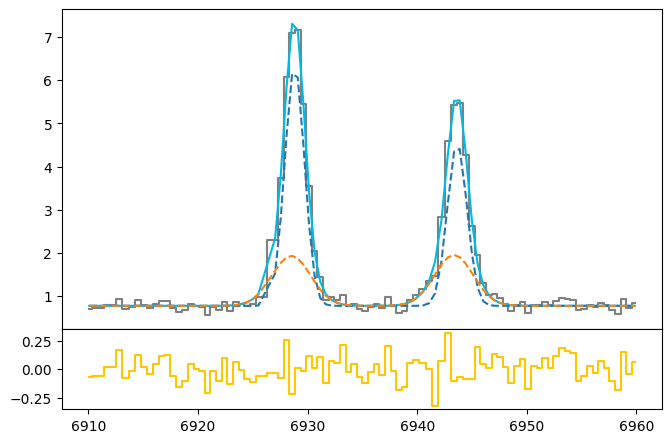

In [46]:
siia_nar_flux = out2_sii.params['Siia_nar'].value
siia_nar_std = out2_sii.params['Siia_nar'].stderr

siia_brd_flux = out2_sii.params['Siia_brd'].value
siia_brd_std = out2_sii.params['Siia_brd'].stderr

siib_nar_flux = out2_sii.params['Siib_nar'].value
siib_nar_std = out2_sii.params['Siib_nar'].stderr

siib_brd_flux = out2_sii.params['Siib_brd'].value
siib_brd_std = out2_sii.params['Siib_brd'].stderr

z_sii = out2_sii.params['z_nar'].value
z_sii_std = out2_sii.params['z_nar'].stderr

bkg_sii = out2_sii.params['bkg'].value
bkg_sii_std = out2_sii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(sii.wavelength, sii.flux, color='gray', label='Data', where='mid')

siia_nar = gaussian(sii.wavelength, siia_nar_flux, wave_cat['[SII]6730'], z_sii, upy.nominal_values(sigma_nar_6730))
siib_nar = gaussian(sii.wavelength, siib_nar_flux, wave_cat['[SII]6716'], z_sii, upy.nominal_values(sigma_nar_6730))

siia_brd = gaussian(sii.wavelength, siia_brd_flux, wave_cat['[SII]6730'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))
siib_brd = gaussian(sii.wavelength, siib_brd_flux, wave_cat['[SII]6716'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

ax.plot(sii.wavelength, bkg_sii + siia + siib, color=c[0])
ax.plot(sii.wavelength, bkg_sii + siia_nar + siib_nar, ls='--')
ax.plot(sii.wavelength, bkg_sii + siia_brd + siib_brd, ls='--')
#plt.yscale('log')
ax1.step(sii.wavelength, sii.flux - bkg_sii - siia - siib, color=c[3], where='mid')

In [47]:
# EW
EW_SII_6730_nar = ufloat(siia_nar_flux, siia_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730_brd = ufloat(siia_brd_flux, siia_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730 = (ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

EW_SII_6716_nar = ufloat(siib_nar_flux, siib_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716_brd = ufloat(siib_brd_flux, siib_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716 = (ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

# H$\beta$

In [48]:
sigma_arc_hb = (m * wave_cat['Hb']*(1 + z_BN[igal])) + n

sigma_nar_hb = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hb**2))
sigma_brd_hb = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hb**2))

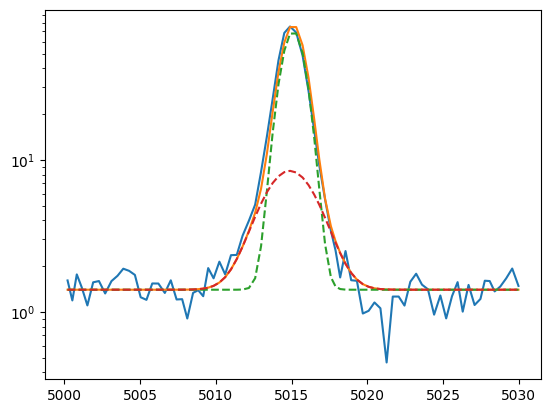

In [49]:
plt.plot(hbeta.wavelength, hbeta.flux)
bkg = 1.4

hb_nar = gaussian(hbeta.wavelength, 1.3e2, wave_cat['Hb'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, 3.0e1, wave_cat['Hb'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

plt.plot(hbeta.wavelength, hb + bkg)
plt.plot(hbeta.wavelength, hb_nar + bkg, ls='--')
plt.plot(hbeta.wavelength, hb_brd + bkg, ls='--')
plt.yscale('log')

In [50]:
params_hb = Parameters()
params_hb.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hb.add('z_ratio', value=z_ratio, vary=False)
params_hb.add('sigma_nar', value=upy.nominal_values(sigma_nar_hb), vary=False)
params_hb.add('sigma_brd', value=upy.nominal_values(sigma_brd_hb), vary=False)
params_hb.add('Hb_nar', value=1.3e2, min=0.)
params_hb.add('Hb_brd', value=3.0e1, min=0.)
params_hb.add('bkg', value=1.4, min=0.)

def residual_hb(params_hb, x, data, uncertainty):
    
    z_nar = params_hb['z_nar']
    z_brd = params_hb['z_nar'] * params_hb['z_ratio']
    sigma_nar = params_hb['sigma_nar']
    sigma_brd = params_hb['sigma_brd']
    hb_nar_flux = params_hb['Hb_nar']
    hb_brd_flux = params_hb['Hb_brd']
    bkg = params_hb['bkg']
    
    x = hbeta.wavelength
    model = gaussian(x, hb_nar_flux, wave_cat['Hb'], z_nar, sigma_nar) + \
            gaussian(x, hb_brd_flux, wave_cat['Hb'], z_brd, sigma_brd)
    return (model + bkg - hbeta.flux) / hbeta.noise

In [51]:
np.random.seed(1624)
out_hb = minimize(residual_hb, params_hb, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:31<00:00, 80.35it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [23.80851279 51.69015493 58.80092462 43.3947527 ]


In [52]:
out_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03160153,1.0286e-06,(0.00%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.75303801,,,0.753038009398489,-inf,inf,False
sigma_brd,1.69209054,,,1.692090542171433,-inf,inf,False
Hb_nar,126.474135,1.10252870,(0.87%),130.0,0.00000000,inf,True
Hb_brd,35.1033162,1.24708784,(3.55%),30.0,0.00000000,inf,True
bkg,1.37869396,0.03645953,(2.64%),1.4,0.00000000,inf,True


In [53]:
np.random.seed(1624)
out2_hb = minimize(residual_hb, out_hb.params, args=(1, 1, 1),
                   method='leastsq')

In [54]:
out2_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03160153,1.2169e-06,(0.00%),0.03160152972738847,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.75303801,0.00000000,(0.00%),0.753038009398489,-inf,inf,False
sigma_brd,1.69209054,0.00000000,(0.00%),1.692090542171433,-inf,inf,False
Hb_nar,126.468202,1.31432090,(1.04%),126.47413541466364,0.00000000,inf,True
Hb_brd,35.0757578,1.50467693,(4.29%),35.103316248462036,0.00000000,inf,True
bkg,1.37841373,0.04357698,(3.16%),1.3786939623565564,0.00000000,inf,True


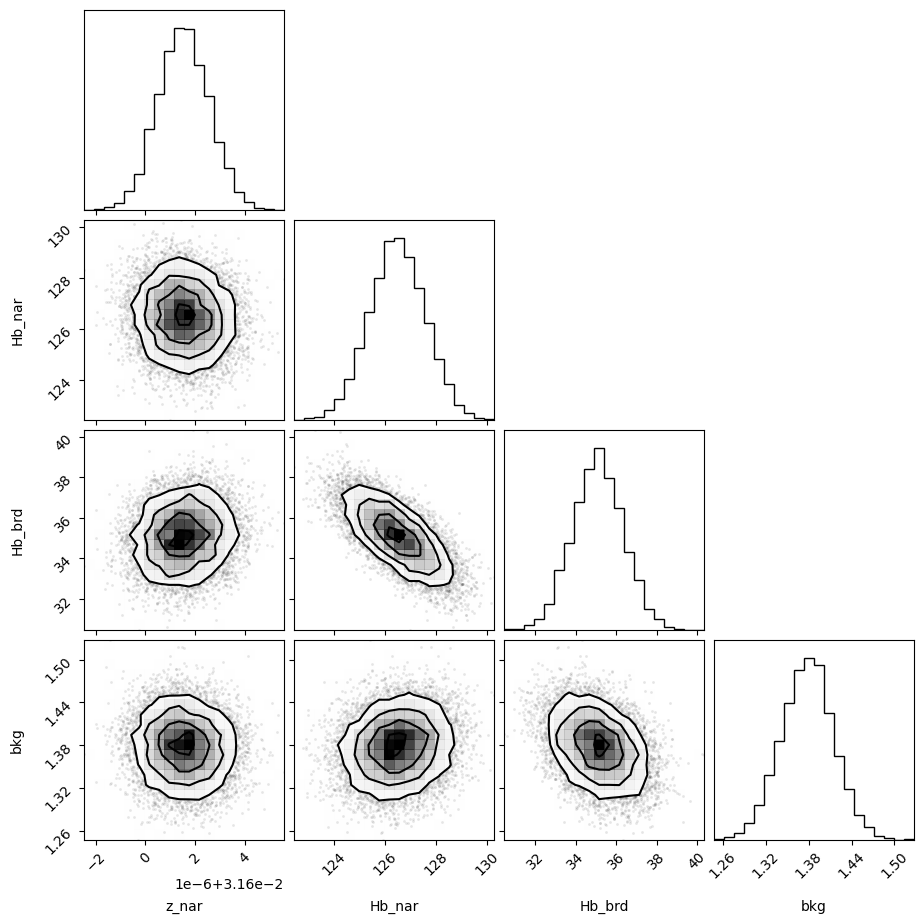

In [55]:
corner.corner(out_hb.flatchain, labels=out_hb.var_names);

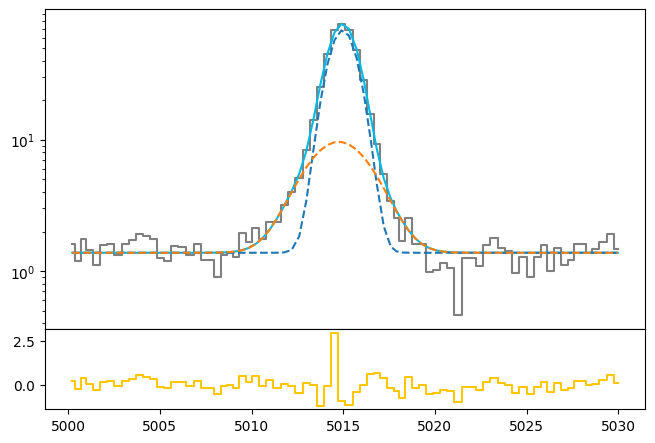

In [56]:
hb_nar_flux = out2_hb.params['Hb_nar'].value
hb_nar_std = out2_hb.params['Hb_nar'].stderr

hb_brd_flux = out2_hb.params['Hb_brd'].value
hb_brd_std = out2_hb.params['Hb_brd'].stderr

z_hb = out2_hb.params['z_nar'].value
z_hb_std = out2_hb.params['z_nar'].stderr

bkg_hb = out2_hb.params['bkg'].value
bkg_hb_std = out2_hb.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hbeta.wavelength, hbeta.flux, color='gray', label='Data', where='mid')

hb_nar = gaussian(hbeta.wavelength, hb_nar_flux, wave_cat['Hb'], z_hb, upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, hb_brd_flux, wave_cat['Hb'], z_hb * z_ratio, upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

ax.plot(hbeta.wavelength, bkg_hb + hb, color=c[0])
ax.plot(hbeta.wavelength, bkg_hb + hb_nar, ls='--')
ax.plot(hbeta.wavelength, bkg_hb + hb_brd, ls='--')
ax.set_yscale('log')
ax1.step(hbeta.wavelength, hbeta.flux - bkg_hb - hb, color=c[3], where='mid')

In [57]:
# EW
EW_Hb_nar = ufloat(hb_nar_flux, hb_nar_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb_brd = ufloat(hb_brd_flux, hb_brd_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb = (ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / ufloat(bkg_hb, bkg_hb_std)

# H$\gamma$

In [58]:
sigma_arc_hg = (m * wave_cat['Hg']*(1 + z_BN[igal])) + n

sigma_nar_hg = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hg**2))
sigma_brd_hg = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hg**2))

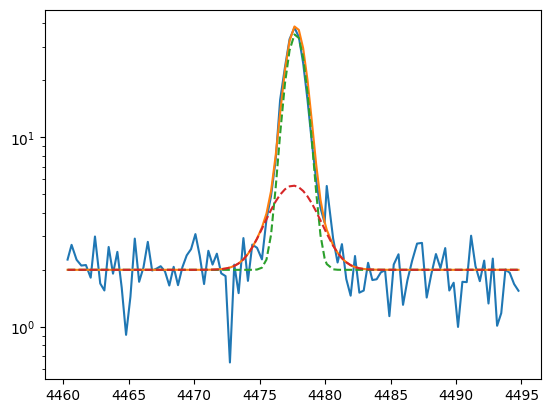

In [59]:
plt.plot(hgamma.wavelength, hgamma.flux)
bkg = 2

hg_nar = gaussian(hgamma.wavelength, 6e1, wave_cat['Hg'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, 1.5e1, wave_cat['Hg'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

plt.plot(hgamma.wavelength, hg + bkg)
plt.plot(hgamma.wavelength, hg_nar + bkg, ls='--')
plt.plot(hgamma.wavelength, hg_brd + bkg, ls='--')
plt.yscale('log')

In [60]:
params_hg = Parameters()
params_hg.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hg.add('z_ratio', value=z_ratio, vary=False)
params_hg.add('sigma_nar', value=upy.nominal_values(sigma_nar_hg), vary=False)
params_hg.add('sigma_brd', value=upy.nominal_values(sigma_brd_hg), vary=False)
params_hg.add('Hg_nar', value=6.0e1, min=0.)
params_hg.add('Hg_brd', value=1.5e1, min=0.)
params_hg.add('bkg', value=2.0, min=0.)

def residual_hg(params_hg, x, data, uncertainty):
    
    z_nar = params_hg['z_nar']
    z_brd = params_hg['z_nar'] * params_hg['z_ratio']
    sigma_nar = params_hg['sigma_nar']
    sigma_brd = params_hg['sigma_brd']
    hg_nar_flux = params_hg['Hg_nar']
    hg_brd_flux = params_hg['Hg_brd']
    bkg = params_hg['bkg']
    
    x = hgamma.wavelength
    model = gaussian(x, hg_nar_flux, wave_cat['Hg'], z_nar, sigma_nar) + \
            gaussian(x, hg_brd_flux, wave_cat['Hg'], z_brd, sigma_brd)
    return (model + bkg - hgamma.flux) / hgamma.noise

In [61]:
np.random.seed(1624)
out_hg = minimize(residual_hg, params_hg, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:35<00:00, 70.01it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [37.47784834 41.72948759 57.94487035 39.08626355]


In [62]:
out_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03160483,2.4275e-06,(0.01%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.71908045,,,0.7190804481164529,-inf,inf,False
sigma_brd,1.67725396,,,1.6772539611431938,-inf,inf,False
Hg_nar,59.3418679,1.13587825,(1.91%),60.0,0.00000000,inf,True
Hg_brd,9.87591983,1.45195058,(14.70%),15.0,0.00000000,inf,True
bkg,1.98110761,0.04893224,(2.47%),2.0,0.00000000,inf,True


In [63]:
np.random.seed(1624)
out2_hg = minimize(residual_hg, out_hg.params, args=(1, 1, 1),
                   method='leastsq')

In [64]:
out2_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03160472,2.7173e-06,(0.01%),0.03160483142877446,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.71908045,0.00000000,(0.00%),0.7190804481164529,-inf,inf,False
sigma_brd,1.67725396,0.00000000,(0.00%),1.6772539611431938,-inf,inf,False
Hg_nar,59.2826496,1.27212276,(2.15%),59.341867902434316,0.00000000,inf,True
Hg_brd,9.94027064,1.64023776,(16.50%),9.87591982787572,0.00000000,inf,True
bkg,1.98176388,0.05530064,(2.79%),1.981107605705469,0.00000000,inf,True


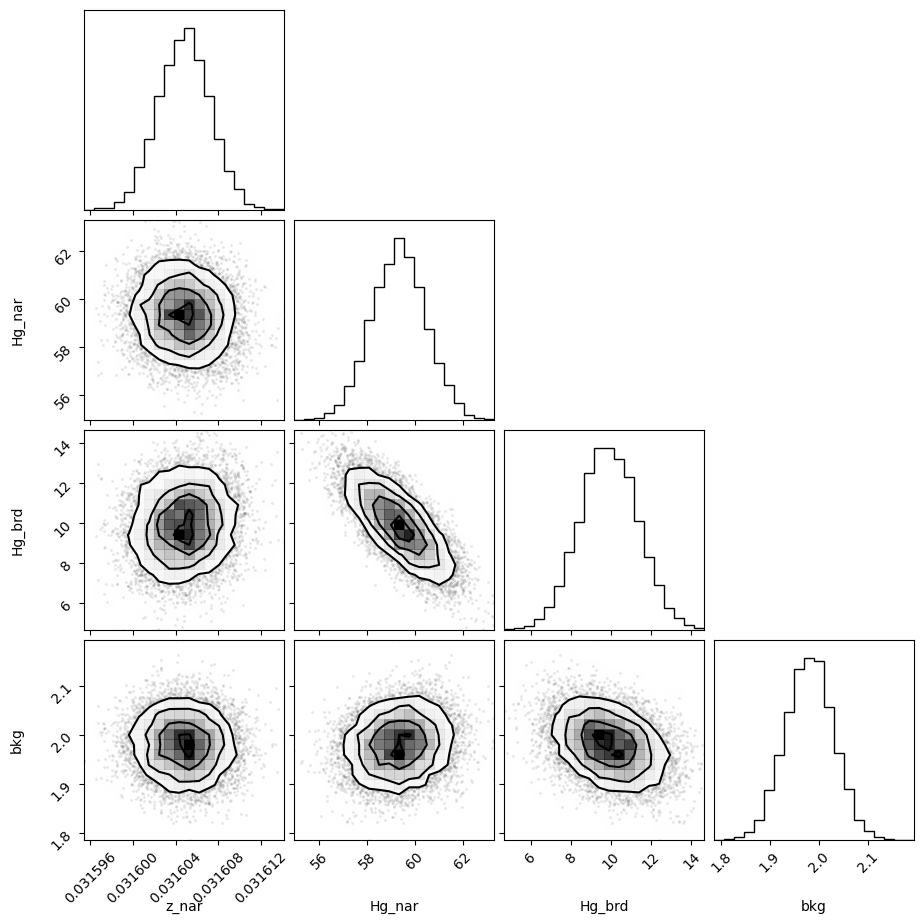

In [65]:
corner.corner(out_hg.flatchain, labels=out_hg.var_names);

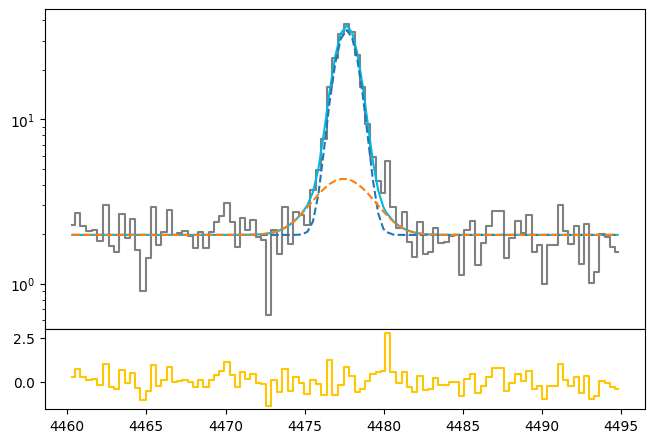

In [66]:
hg_nar_flux = out2_hg.params['Hg_nar'].value
hg_nar_std = out2_hg.params['Hg_nar'].stderr

hg_brd_flux = out2_hg.params['Hg_brd'].value
hg_brd_std = out2_hg.params['Hg_brd'].stderr

z_hg = out2_hg.params['z_nar'].value
z_hg_std = out2_hg.params['z_nar'].stderr

bkg_hg = out2_hg.params['bkg'].value
bkg_hg_std = out2_hg.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hgamma.wavelength, hgamma.flux, color='gray', label='Data', where='mid')

hg_nar = gaussian(hgamma.wavelength, hg_nar_flux, wave_cat['Hg'],           z_hg, upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, hg_brd_flux, wave_cat['Hg'], z_hg * z_ratio, upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

ax.plot(hgamma.wavelength, bkg_hg + hg, color=c[0])
ax.plot(hgamma.wavelength, bkg_hg + hg_nar, ls='--')
ax.plot(hgamma.wavelength, bkg_hg + hg_brd, ls='--')
ax.set_yscale('log')
ax1.step(hgamma.wavelength, hgamma.flux - bkg_hg - hg, color=c[3], where='mid')

In [67]:
# EW
EW_Hg_nar = ufloat(hg_nar_flux, hg_nar_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg_brd = ufloat(hg_brd_flux, hg_brd_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg = (ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / ufloat(bkg_hg, bkg_hg_std)

# H$\delta$

In [68]:
sigma_arc_hd = (m * wave_cat['Hd']*(1 + z_BN[igal])) + n

sigma_nar_hd = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hd**2))
sigma_brd_hd = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hd**2))

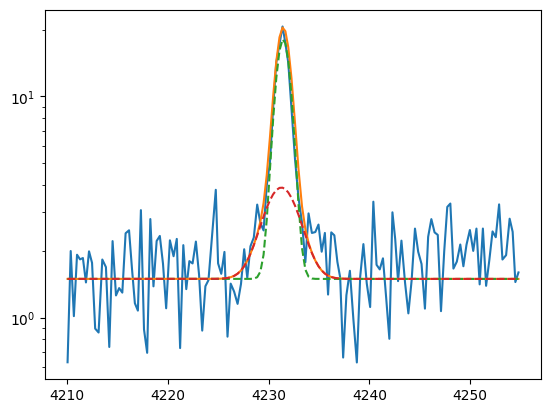

In [69]:
plt.plot(hdelta.wavelength, hdelta.flux)
bkg = 1.5

hd_nar = gaussian(hdelta.wavelength, 3e1, wave_cat['Hd'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hg))
hd_brd = gaussian(hdelta.wavelength, 1e1, wave_cat['Hd'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hg))

hd = hd_nar + hd_brd

plt.plot(hdelta.wavelength, hd + bkg)
plt.plot(hdelta.wavelength, hd_nar + bkg, ls='--')
plt.plot(hdelta.wavelength, hd_brd + bkg, ls='--')
plt.yscale('log')

In [70]:
params_hd = Parameters()
params_hd.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hd.add('z_ratio', value=z_ratio, vary=False)
params_hd.add('sigma_nar', value=upy.nominal_values(sigma_nar_hg), vary=False)
params_hd.add('sigma_brd', value=upy.nominal_values(sigma_brd_hg), vary=False)
params_hd.add('Hd_nar', value=3.0e1, min=0.)
params_hd.add('Hd_brd', value=0., vary=False)
params_hd.add('bkg', value=1.5, min=0.)

def residual_hd(params_hd, x, data, uncertainty):
    
    z_nar = params_hd['z_nar']
    z_brd = params_hd['z_nar'] * params_hd['z_ratio']
    sigma_nar = params_hd['sigma_nar']
    sigma_brd = params_hd['sigma_brd']
    hd_nar_flux = params_hd['Hd_nar']
    hd_brd_flux = params_hd['Hd_brd']
    bkg = params_hd['bkg']
    
    x = hdelta.wavelength
    model = gaussian(x, hd_nar_flux, wave_cat['Hd'], z_nar, sigma_nar) + \
            gaussian(x, hd_brd_flux, wave_cat['Hd'], z_brd, sigma_brd)
    return (model + bkg - hdelta.flux) / hdelta.noise

In [71]:
np.random.seed(1624)
out_hd = minimize(residual_hd, params_hd, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:43<00:00, 57.31it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [32.9655096  34.13486304 58.83602102]


In [72]:
out_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03160913,4.9923e-06,(0.02%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.71908045,,,0.7190804481164529,-inf,inf,False
sigma_brd,1.67725396,,,1.6772539611431938,-inf,inf,False
Hd_nar,30.9586674,0.71949505,(2.32%),30.0,0.00000000,inf,True
Hd_brd,0.00000000,,,0.0,-inf,inf,False
bkg,1.81866222,0.04981420,(2.74%),1.5,0.00000000,inf,True


In [73]:
np.random.seed(1624)
out2_hd = minimize(residual_hd, out_hd.params, args=(1, 1, 1),
                   method='leastsq')

In [74]:
out2_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03160907,5.4865e-06,(0.02%),0.03160913230697732,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.71908045,0.00000000,(0.00%),0.7190804481164529,-inf,inf,False
sigma_brd,1.67725396,0.00000000,(0.00%),1.6772539611431938,-inf,inf,False
Hd_nar,30.9923005,0.76692290,(2.47%),30.958667391769502,0.00000000,inf,True
Hd_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,1.81829581,0.05481254,(3.01%),1.8186622170434328,0.00000000,inf,True


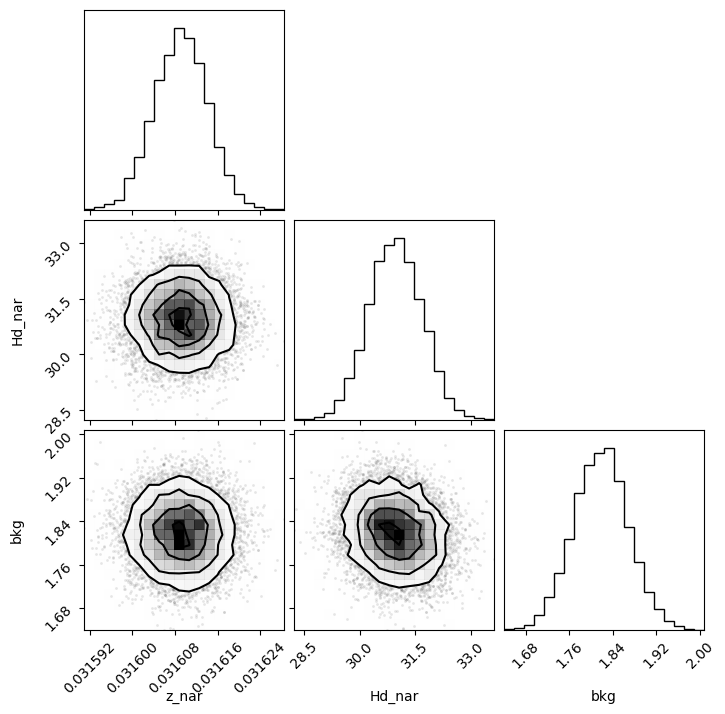

In [75]:
corner.corner(out_hd.flatchain, labels=out_hd.var_names);

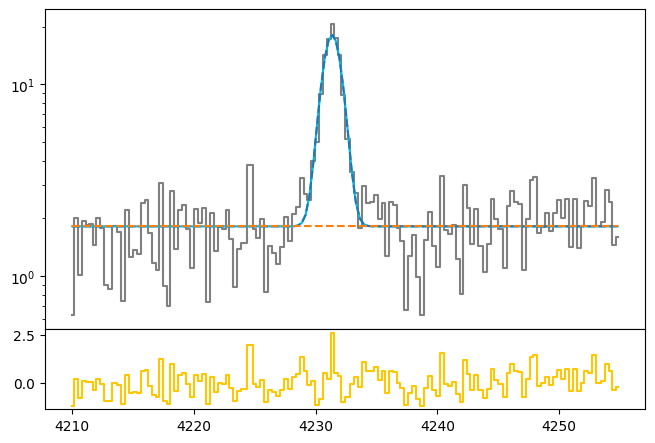

In [76]:
hd_nar_flux = out2_hd.params['Hd_nar'].value
hd_nar_std = out2_hd.params['Hd_nar'].stderr

hd_brd_flux = out2_hd.params['Hd_brd'].value
hd_brd_std = out2_hd.params['Hd_brd'].stderr

z_hd = out2_hd.params['z_nar'].value
z_hd_std = out2_hd.params['z_nar'].stderr

bkg_hd = out2_hd.params['bkg'].value
bkg_hd_std = out2_hd.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hdelta.wavelength, hdelta.flux, color='gray', label='Data', where='mid')

hd_nar = gaussian(hdelta.wavelength, hd_nar_flux, wave_cat['Hd'], z_hd, sigma_nar_oiii_4959)
hd_brd = gaussian(hdelta.wavelength, hd_brd_flux, wave_cat['Hd'], z_hd * z_ratio, sigma_brd_oiii_4959)

hd = hd_nar + hd_brd

ax.plot(hdelta.wavelength, bkg_hd + hd, color=c[0])
ax.plot(hdelta.wavelength, bkg_hd + hd_nar, ls='--')
ax.plot(hdelta.wavelength, bkg_hd + hd_brd, ls='--')
ax.set_yscale('log')
ax1.step(hdelta.wavelength, hdelta.flux - bkg_hd - hd, color=c[3], where='mid')

In [77]:
# EW
EW_Hd_nar = ufloat(hd_nar_flux, hd_nar_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd_brd = ufloat(hd_brd_flux, hd_brd_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd = (ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / ufloat(bkg_hd, bkg_hd_std)

# [OII]3726 + [OII]3729

In [78]:
sigma_arc_3729 = (m * wave_cat['[OII]3729']*(1 + z_BN[igal])) + n

sigma_nar_3729 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_3729**2))
sigma_brd_3729 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3729**2))

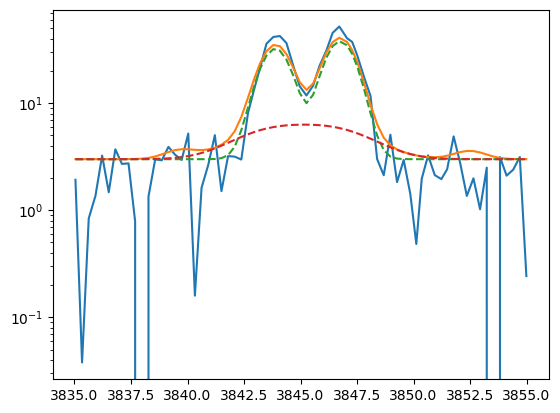

In [79]:
# Search for good initial guess

plt.plot(oii_3727.wavelength, oii_3727.flux)

h13 = gaussian(oii_3727.wavelength, 1, wave_cat['H13'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, 6.0e1, wave_cat['[OII]3729'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, 1.0e1, wave_cat['[OII]3729'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, 5.0e1, wave_cat['[OII]3726'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, 1.0e1, wave_cat['[OII]3726'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, 1, wave_cat['H14'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

bkg = 3

plt.plot(oii_3727.wavelength, bkg + oiid + oiic + h13 + h14)
plt.plot(oii_3727.wavelength, bkg + oiid_nar + oiic_nar, ls='--')
plt.plot(oii_3727.wavelength, bkg + oiid_brd + oiic_brd, ls='--')

plt.yscale('log')

In [80]:
params_oii_3727 = Parameters()

params_oii_3727.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_3727.add('z_ratio', value=z_ratio, vary=False)
params_oii_3727.add('sigma_nar', value=upy.nominal_values(sigma_nar_3729), vary=False)
params_oii_3727.add('sigma_brd', value=upy.nominal_values(sigma_brd_3729), vary=False)
params_oii_3727.add('H13', value=1, min=0.)
params_oii_3727.add('Oiic_nar', value=6.0e1, min=0.)
params_oii_3727.add('Oiic_brd', value=0., vary=False)
params_oii_3727.add('Oiid_nar', value=6.0e1, min=0.)
params_oii_3727.add('Oiid_brd', value=0., vary=False)
params_oii_3727.add('H14', value=1, min=0.)
params_oii_3727.add('bkg', value=3, min=0.)

def residual_oii_3727(params_oii_3727, x, data, uncertainty):
    
    z_nar = params_oii_3727['z_nar']
    z_brd = params_oii_3727['z_nar'] * params_oii_3727['z_ratio']
    sigma_nar = params_oii_3727['sigma_nar']
    sigma_brd = params_oii_3727['sigma_brd']
    
    h13_flux = params_oii_3727['H13']
    oiic_nar_flux = params_oii_3727['Oiic_nar']
    oiic_brd_flux = params_oii_3727['Oiic_brd']
    oiid_nar_flux = params_oii_3727['Oiid_nar']
    oiid_brd_flux = params_oii_3727['Oiid_brd']
    h14_flux = params_oii_3727['H14']
    bkg = params_oii_3727['bkg']
    
    x = oii_3727.wavelength
    model_h13 = gaussian(x, h13_flux, wave_cat['H13'], z_nar, sigma_nar)
    model_oiic = gaussian(x, oiic_nar_flux, wave_cat['[OII]3729'], z_nar, sigma_nar) + \
                 gaussian(x, oiic_brd_flux, wave_cat['[OII]3729'], z_brd, sigma_brd)
    model_oiid = gaussian(x, oiid_nar_flux, wave_cat['[OII]3726'], z_nar, sigma_nar) + \
                 gaussian(x, oiid_brd_flux, wave_cat['[OII]3726'], z_brd, sigma_brd)
    model_h14 = gaussian(x, h14_flux, wave_cat['H14'], z_nar, sigma_nar)
    model = model_h13 + model_oiic + model_oiid + model_h14
    return (model + bkg - oii_3727.flux) / oii_3727.noise

In [81]:
np.random.seed(1624)
out_oii_3727 = minimize(residual_oii_3727, params_oii_3727, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [01:11<00:00, 35.14it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [55.58228826 60.81222437 84.03235377 83.3999233  72.87020156 80.37800676]


In [82]:
out_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03164029,3.0279e-06,(0.01%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.68265397,,,0.6826539722973715,-inf,inf,False
sigma_brd,1.66196288,,,1.6619628772029043,-inf,inf,False
H13,1.02593414,0.80200950,(78.17%),1,0.00000000,inf,True
Oiic_nar,81.2677947,1.52644955,(1.88%),60.0,0.00000000,inf,True
Oiic_brd,0.00000000,,,0.0,-inf,inf,False
Oiid_nar,68.1605039,1.37807935,(2.02%),60.0,0.00000000,inf,True
Oiid_brd,0.00000000,,,0.0,-inf,inf,False
H14,2.59496934,1.04935512,(40.44%),1,0.00000000,inf,True


In [83]:
np.random.seed(1624)
out2_oii_3727 = minimize(residual_oii_3727, out_oii_3727.params, args=(1, 1, 1),
                         method='leastsq')

In [84]:
out2_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03164040,3.9892e-06,(0.01%),0.03164028977512918,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.68265397,0.00000000,(0.00%),0.6826539722973715,-inf,inf,False
sigma_brd,1.66196288,0.00000000,(0.00%),1.6619628772029043,-inf,inf,False
H13,0.61421487,1.36020167,(221.45%),1.0259341350431077,0.00000000,inf,True
Oiic_nar,81.1759772,1.98529295,(2.45%),81.26779468311197,0.00000000,inf,True
Oiic_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
Oiid_nar,68.1187234,1.73898481,(2.55%),68.16050385085411,0.00000000,inf,True
Oiid_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
H14,2.49640023,1.36364303,(54.62%),2.594969339610843,0.00000000,inf,True


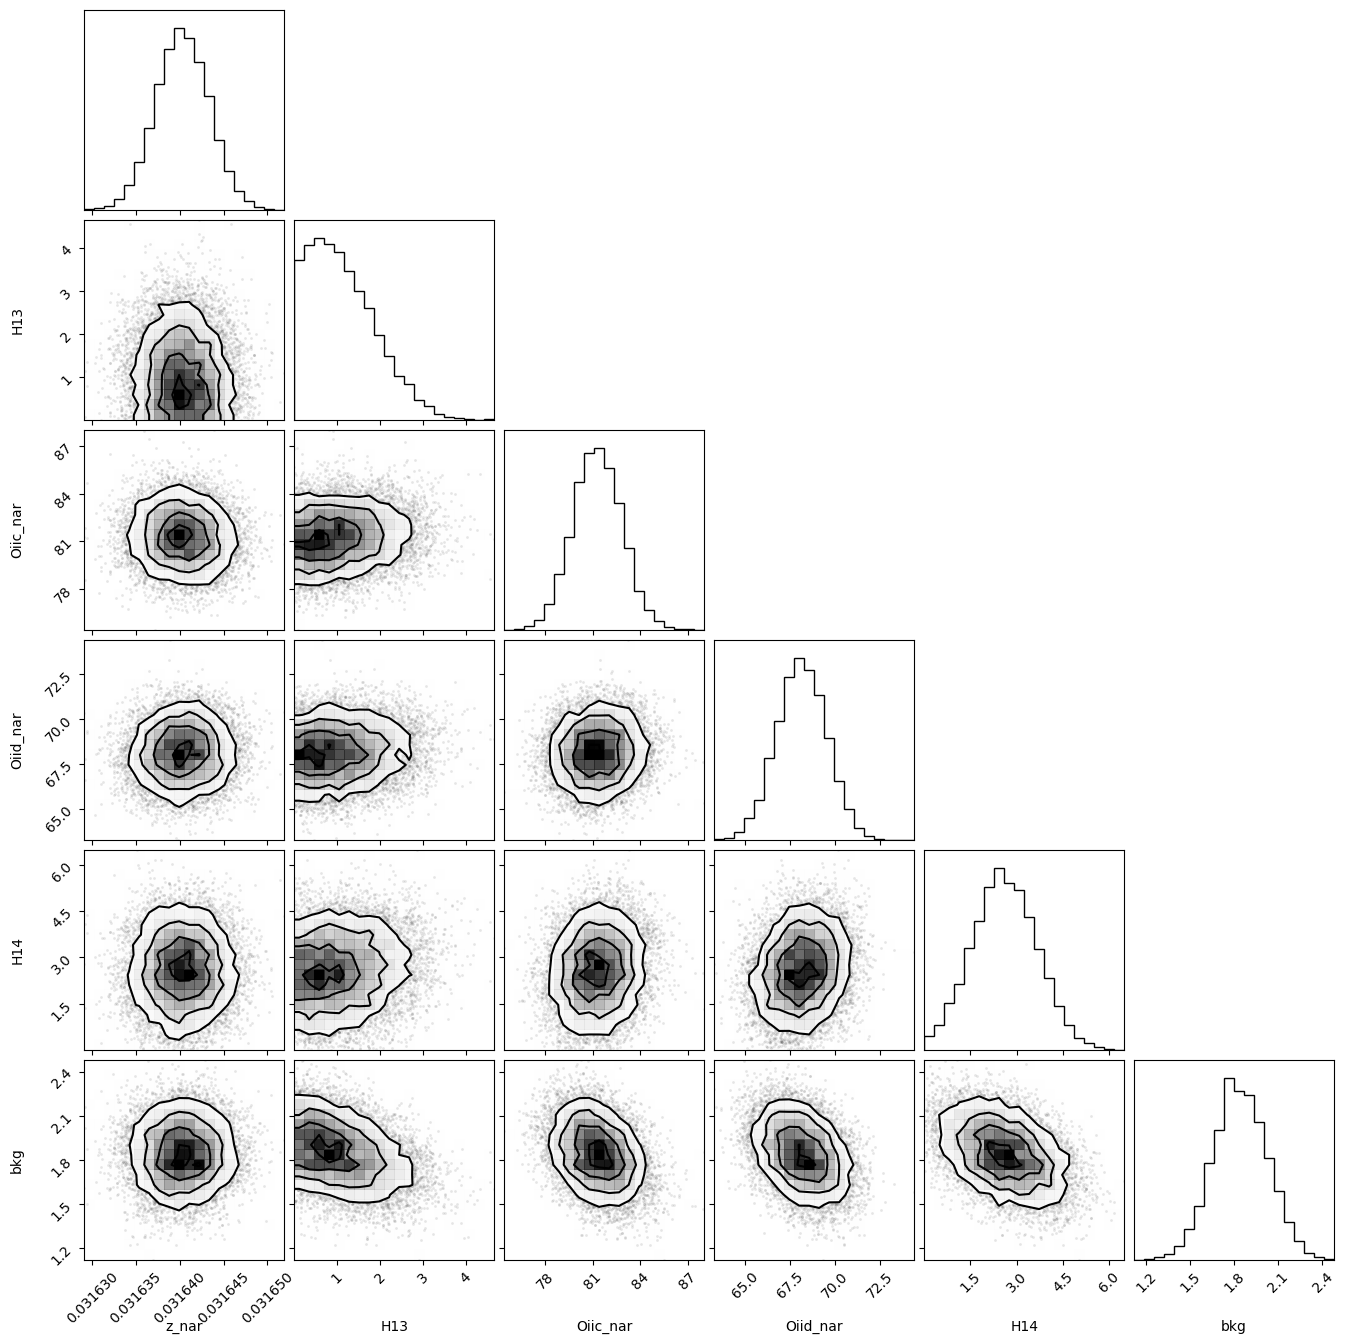

In [85]:
corner.corner(out_oii_3727.flatchain, labels=out_oii_3727.var_names);

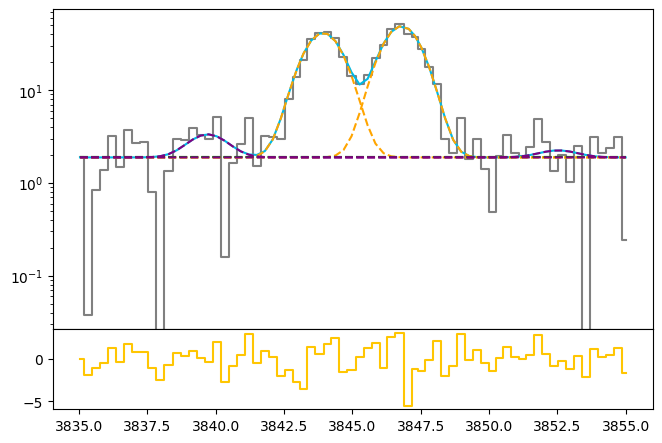

In [86]:
h13_flux = out2_oii_3727.params['H13'].value
h13_std = out2_oii_3727.params['H13'].stderr

oiic_nar_flux = out2_oii_3727.params['Oiic_nar'].value
oiic_nar_std = out2_oii_3727.params['Oiic_nar'].stderr

oiic_brd_flux = out2_oii_3727.params['Oiic_brd'].value
oiic_brd_std = out2_oii_3727.params['Oiic_brd'].stderr

oiid_nar_flux = out2_oii_3727.params['Oiid_nar'].value
oiid_nar_std = out2_oii_3727.params['Oiid_nar'].stderr

oiid_brd_flux = out2_oii_3727.params['Oiid_brd'].value
oiid_brd_std = out2_oii_3727.params['Oiid_brd'].stderr

h14_flux = out2_oii_3727.params['H14'].value
h14_std = out2_oii_3727.params['H14'].stderr

z_oii_3727 = out2_oii_3727.params['z_nar'].value
z_oii_3727_std = out2_oii_3727.params['z_nar'].stderr

bkg_oii_3727 = out2_oii_3727.params['bkg'].value
bkg_oii_3727_std = out2_oii_3727.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_3727.wavelength, oii_3727.flux, color='gray', label='Data', where='mid')

h13 = gaussian(oii_3727.wavelength, h13_flux, wave_cat['H13'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, oiic_nar_flux, wave_cat['[OII]3729'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, oiic_brd_flux, wave_cat['[OII]3729'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, oiid_nar_flux, wave_cat['[OII]3726'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, oiid_brd_flux, wave_cat['[OII]3726'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, h14_flux, wave_cat['H14'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13 + oiic + oiid + h14, color=c[0])
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13, ls='--', color='purple')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h14, ls='--', color='purple')

ax.set_yscale('log')
ax1.step(oii_3727.wavelength, oii_3727.flux - bkg_oii_3727 - oiic - oiid - h13 - h14,
         color=c[3], where='mid')

In [87]:
# EW
EW_OII_3729_nar = ufloat(oiic_nar_flux, oiic_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729_brd = ufloat(oiic_brd_flux, oiic_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729 = (ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

EW_OII_3726_nar = ufloat(oiid_nar_flux, oiid_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726_brd = ufloat(oiid_brd_flux, oiid_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726 = (ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

# [SIII]9532

In [88]:
sigma_arc_9532 = (m * wave_cat['[SIII]9532']*(1 + z_BN[igal])) + n

sigma_nar_9532 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_9532**2))
sigma_brd_9532 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_9532**2))

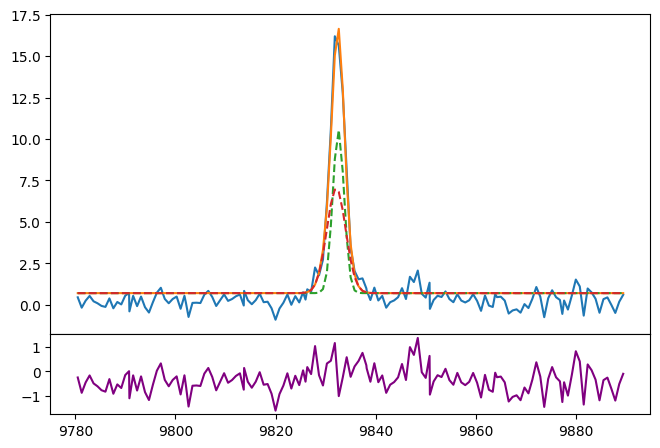

In [89]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9532.wavelength, siii_9532.flux)
bkg = 7e-1

siiia_nar = gaussian(siii_9532.wavelength, 0.28e2, wave_cat['[SIII]9532'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_9532))
siiia_brd = gaussian(siii_9532.wavelength, 0.3e2, wave_cat['[SIII]9532'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_9532))

ax.plot(siii_9532.wavelength, bkg + siiia_nar + siiia_brd)
ax.plot(siii_9532.wavelength, bkg + siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, bkg + siiia_brd, ls='--')
ax1.plot(siii_9532.wavelength, siii_9532.flux - bkg - siiia_nar - siiia_brd, color='purple')
#ax.set_yscale('log')

In [90]:
params_siiia = Parameters()
params_siiia.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiia.add('z_ratio', value=z_ratio, vary=False)
params_siiia.add('sigma_nar', value=upy.nominal_values(sigma_nar_9532), vary=False)
params_siiia.add('sigma_brd', value=upy.nominal_values(sigma_brd_9532), vary=False)
params_siiia.add('Siiia_nar', value=0.28e2, min=0.)
params_siiia.add('Siiia_brd', value=0.3e2, min=0.)
params_siiia.add('bkg', value=7e-1, min=0.)


def residual_siiia(params_siiia, x, data, uncertainty):
    
    z_nar = params_siiia['z_nar']
    z_brd = params_siiia['z_nar'] * params_siiia['z_ratio']
    sigma_nar = params_siiia['sigma_nar']
    sigma_brd = params_siiia['sigma_brd']
    siiia_nar_flux = params_siiia['Siiia_nar']
    siiia_brd_flux = params_siiia['Siiia_brd']
    bkg = params_siiia['bkg']
    
    x = siii_9532.wavelength
    model = gaussian(x, siiia_nar_flux, wave_cat['[SIII]9532'], z_nar, sigma_nar) + \
            gaussian(x, siiia_brd_flux, wave_cat['[SIII]9532'], z_brd, sigma_brd)
    
    return (model + bkg - siii_9532.flux) / siii_9532.noise

In [91]:
np.random.seed(1624)
out_siiia = minimize(residual_siiia, params_siiia, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:50<00:00, 49.08it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [36.15297636 45.03924415 52.28568835 76.94996335]


In [92]:
out_siiia.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03163102,4.5004e-06,(0.01%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,1.13252515,,,1.132525150715074,-inf,inf,False
sigma_brd,1.89174982,,,1.8917498186360098,-inf,inf,False
Siiia_nar,23.2333967,2.55927730,(11.02%),28.0,0.00000000,inf,True
Siiia_brd,38.9228846,3.06254941,(7.87%),30.0,0.00000000,inf,True
bkg,0.30876348,0.03133815,(10.15%),0.7,0.00000000,inf,True


In [93]:
np.random.seed(1624)
out2_siiia = minimize(residual_siiia, out_siiia.params, args=(1, 1, 1),
                      method='leastsq')

In [94]:
out2_siiia.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03163108,5.8043e-06,(0.02%),0.03163101706263001,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,1.13252515,0.00000000,(0.00%),1.132525150715074,-inf,inf,False
sigma_brd,1.89174982,0.00000000,(0.00%),1.8917498186360098,-inf,inf,False
Siiia_nar,23.2388333,3.39099492,(14.59%),23.233396676855094,0.00000000,inf,True
Siiia_brd,39.0007095,4.08314453,(10.47%),38.92288462329827,0.00000000,inf,True
bkg,0.30767661,0.04158345,(13.52%),0.3087634801072143,0.00000000,inf,True


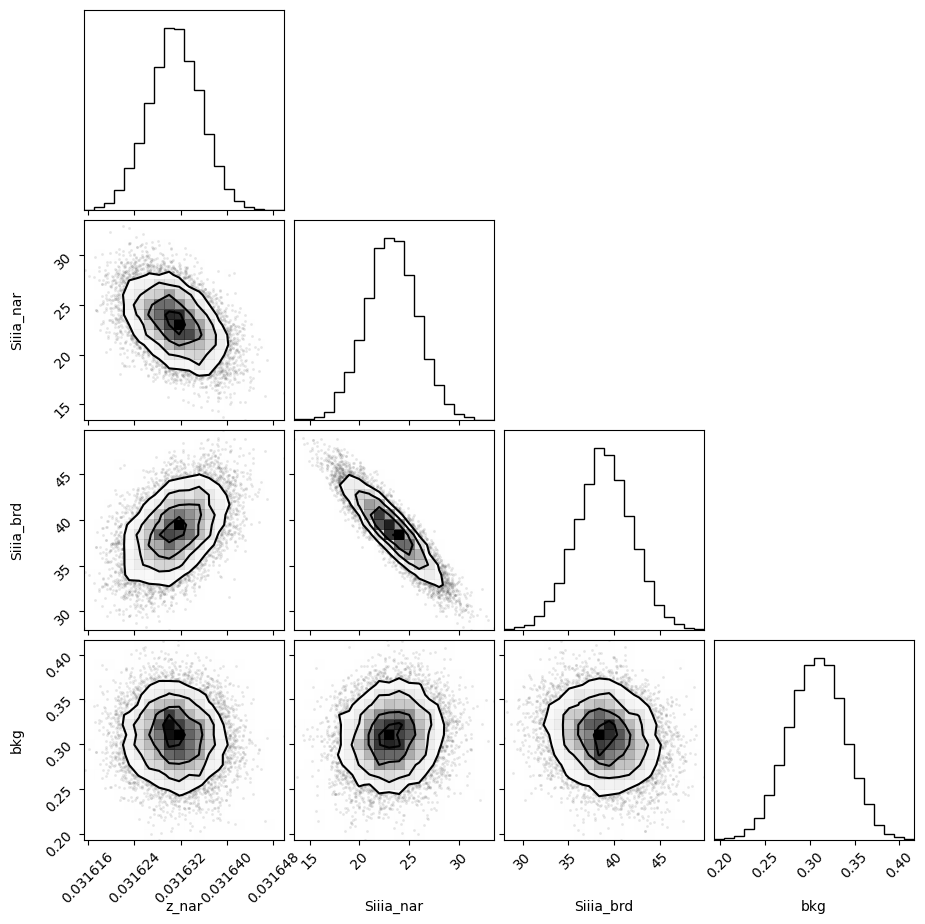

In [95]:
corner.corner(out_siiia.flatchain, labels=out_siiia.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

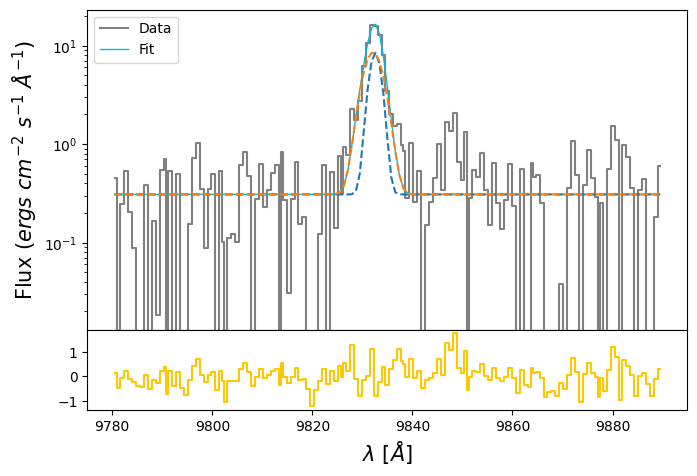

In [96]:
siiia_nar_flux = out2_siiia.params['Siiia_nar'].value
siiia_nar_std = out2_siiia.params['Siiia_nar'].stderr

siiia_brd_flux = out2_siiia.params['Siiia_brd'].value
siiia_brd_std = out2_siiia.params['Siiia_brd'].stderr

z_siiia = out2_siiia.params['z_nar'].value
z_siiia_std = out2_siiia.params['z_nar'].stderr

bkg_siiia = out2_siiia.params['bkg'].value
bkg_siiia_std = out2_siiia.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9532.wavelength, siii_9532.flux,
            color='gray', label='Data', where='mid')

siiia_nar = gaussian(siii_9532.wavelength, siiia_nar_flux, wave_cat['[SIII]9532'], z_siiia, upy.nominal_values(sigma_nar_9532))
siiia_brd = gaussian(siii_9532.wavelength, siiia_brd_flux, wave_cat['[SIII]9532'], z_siiia * z_ratio, upy.nominal_values(sigma_brd_9532))
siiia = siiia_nar + siiia_brd

ax.plot(siii_9532.wavelength, bkg_siiia + siiia, lw=1, color=c[0], label='Fit')
ax.plot(siii_9532.wavelength, bkg_siiia + siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, bkg_siiia + siiia_brd, ls='--')
ax1.step(siii_9532.wavelength, siii_9532.flux - bkg_siiia - siiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [97]:
# EW
EW_SIII_9532_nar = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)
EW_SIII_9532_brd = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)
EW_SIII_9532 = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)

# [SIII]9069

In [98]:
sigma_arc_9069 = (m * wave_cat['[SIII]9069']*(1 + z_BN[igal])) + n

sigma_nar_9069 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_9069**2))
sigma_brd_9069 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_9069**2))

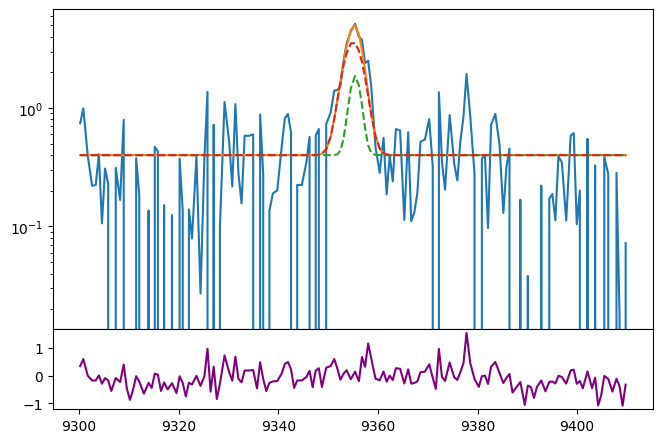

In [99]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9069.wavelength, siii_9069.flux)
bkg = 4e-1

siiib_nar = gaussian(siii_9069.wavelength, 0.4e1, wave_cat['[SIII]9069'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_9069))
siiib_brd = gaussian(siii_9069.wavelength, 1.5e1, wave_cat['[SIII]9069'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_9069))

ax.plot(siii_9069.wavelength, bkg + siiib_nar + siiib_brd)
ax.plot(siii_9069.wavelength, bkg + siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, bkg + siiib_brd, ls='--')
ax1.plot(siii_9069.wavelength, siii_9069.flux - bkg - siiib_nar - siiib_brd, color='purple')
ax.set_yscale('log')

In [100]:
params_siiib = Parameters()
params_siiib.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiib.add('z_ratio', value=z_ratio, vary=False)
params_siiib.add('sigma_nar', value=upy.nominal_values(sigma_nar_9069), vary=False)
params_siiib.add('sigma_brd', value=upy.nominal_values(sigma_brd_9069), vary=False)
params_siiib.add('Siiib_nar', value=0, vary=False)
params_siiib.add('Siiib_brd', value=1.5e1, min=0.)
params_siiib.add('bkg', value=4e-1, min=0.)


def residual_siiib(params_siiib, x, data, uncertainty):
    
    z_nar = params_siiib['z_nar']
    z_brd = params_siiib['z_nar'] * params_siiib['z_ratio']
    sigma_nar = params_siiib['sigma_nar']
    sigma_brd = params_siiib['sigma_brd']
    siiib_nar_flux = params_siiib['Siiib_nar']
    siiib_brd_flux = params_siiib['Siiib_brd']
    bkg = params_siiib['bkg']
    
    x = siii_9069.wavelength
    model = gaussian(x, siiib_nar_flux, wave_cat['[SIII]9069'], z_nar, sigma_nar) + \
            gaussian(x, siiib_brd_flux, wave_cat['[SIII]9069'], z_brd, sigma_brd)
    
    return (model + bkg - siii_9069.flux) / siii_9069.noise

In [101]:
np.random.seed(1624)
out_siiib = minimize(residual_siiib, params_siiib, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:51<00:00, 48.18it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [36.65766294 53.92067764 43.2900405 ]


In [102]:
out_siiib.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03165787,1.0484e-05,(0.03%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,1.09099920,,,1.090999196859649,-inf,inf,False
sigma_brd,1.86718596,,,1.8671859593665476,-inf,inf,False
Siiib_nar,0.00000000,,,0,-inf,inf,False
Siiib_brd,21.6880854,0.83110550,(3.83%),15.0,0.00000000,inf,True
bkg,0.28008794,0.02465462,(8.80%),0.4,0.00000000,inf,True


In [103]:
np.random.seed(1624)
out2_siiib = minimize(residual_siiib, out_siiib.params, args=(1, 1, 1),
                      method='leastsq')

In [104]:
out2_siiib.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03165811,1.2639e-05,(0.04%),0.03165787162213864,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,1.09099920,0.00000000,(0.00%),1.090999196859649,-inf,inf,False
sigma_brd,1.86718596,0.00000000,(0.00%),1.8671859593665476,-inf,inf,False
Siiib_nar,0.00000000,0.00000000,,0,-inf,inf,False
Siiib_brd,21.7129798,1.05762352,(4.87%),21.68808542454037,0.00000000,inf,True
bkg,0.28078819,0.03019917,(10.76%),0.2800879363946544,0.00000000,inf,True


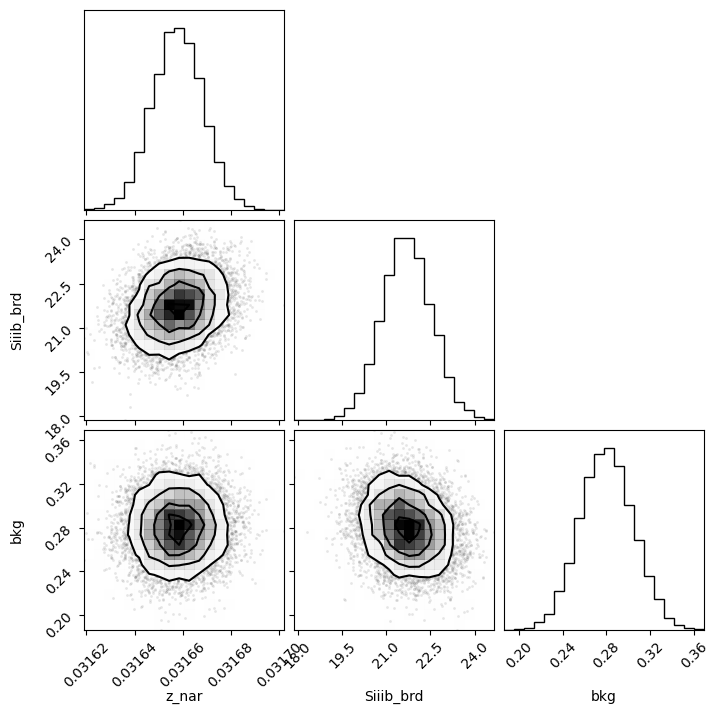

In [105]:
corner.corner(out_siiib.flatchain, labels=out_siiib.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

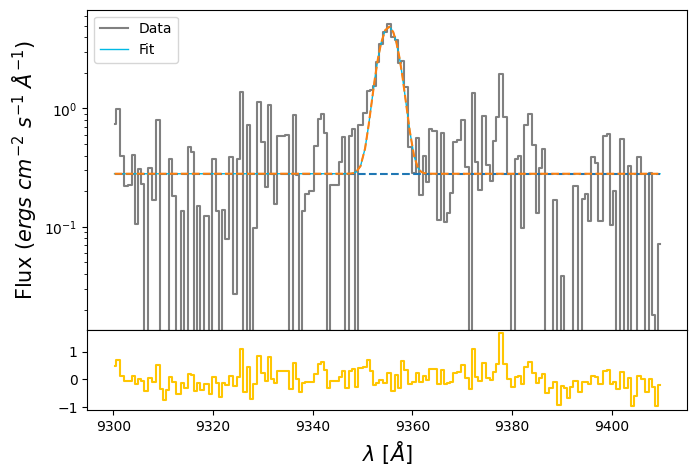

In [106]:
siiib_nar_flux = out2_siiib.params['Siiib_nar'].value
siiib_nar_std = out2_siiib.params['Siiib_nar'].stderr

siiib_brd_flux = out2_siiib.params['Siiib_brd'].value
siiib_brd_std = out2_siiib.params['Siiib_brd'].stderr

z_siiib = out2_siiib.params['z_nar'].value
z_siiib_std = out2_siiib.params['z_nar'].stderr

bkg_siiib = out2_siiib.params['bkg'].value
bkg_siiib_std = out2_siiib.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9069.wavelength, siii_9069.flux,
            color='gray', label='Data', where='mid')

siiib_nar = gaussian(siii_9069.wavelength, siiib_nar_flux, wave_cat['[SIII]9069'], z_siiib, upy.nominal_values(sigma_nar_9069))
siiib_brd = gaussian(siii_9069.wavelength, siiib_brd_flux, wave_cat['[SIII]9069'], z_siiib * z_ratio, upy.nominal_values(sigma_brd_9069))
siiib = siiib_nar + siiib_brd

ax.plot(siii_9069.wavelength, bkg_siiib + siiib, lw=1, color=c[0], label='Fit')
ax.plot(siii_9069.wavelength, bkg_siiib + siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, bkg_siiib + siiib_brd, ls='--')
ax1.step(siii_9069.wavelength, siii_9069.flux - bkg_siiib - siiib, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [107]:
# EW
EW_SIII_9069_nar = ufloat(siiib_nar_flux, siiib_nar_std) / ufloat(bkg_siiib, bkg_siiib_std)
EW_SIII_9069_brd = ufloat(siiib_brd_flux, siiib_brd_std) / ufloat(bkg_siiib, bkg_siiib_std)
EW_SIII_9069 = (ufloat(siiib_nar_flux, siiib_nar_std) + ufloat(siiib_brd_flux, siiib_brd_std)) / ufloat(bkg_siiib, bkg_siiib_std)

# [OI]6300 + [SIII]6312

In [108]:
sigma_arc_6312 = (m * wave_cat['[SIII]6312']*(1 + z_BN[igal])) + n

sigma_nar_6312 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6312**2))
sigma_brd_6312 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6312**2))

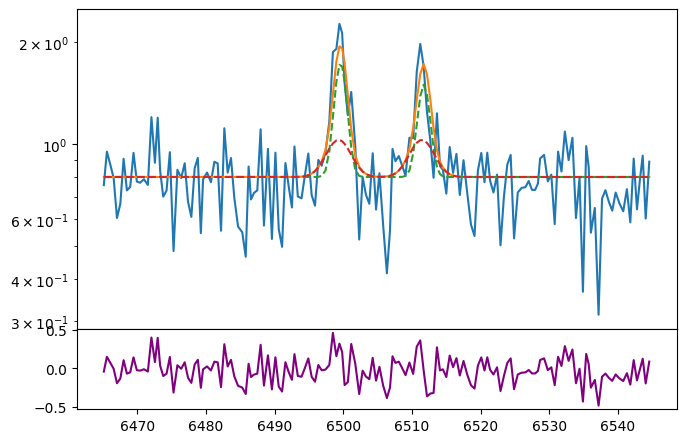

In [109]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oi_siii.wavelength, oi_siii.flux)
bkg = 8e-1

oi_nar = gaussian(oi_siii.wavelength, 0.2e1, wave_cat['[OI]6300'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, 0.1e1, wave_cat['[OI]6300'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, 0.15e1, wave_cat['[SIII]6312'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, 0.1e1, wave_cat['[SIII]6312'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

ax.plot(oi_siii.wavelength, bkg + siiic_nar + siiic_brd + oi_nar + oi_brd)
ax.plot(oi_siii.wavelength, bkg + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg + siiic_brd + oi_brd, ls='--')
ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg - siiic_nar - siiic_brd - oi_nar - oi_brd, color='purple')
ax.set_yscale('log')

In [110]:
params_oi_siii = Parameters()
params_oi_siii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oi_siii.add('z_ratio', value=z_ratio, vary=False)
params_oi_siii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oi_siii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oi_siii.add('Oi_nar', value=0.2e1, min=0.)
params_oi_siii.add('Oi_brd', value=0., vary=False)
params_oi_siii.add('Siiic_nar', value=0.15e1, min=0.)
params_oi_siii.add('Siiic_brd', value=0., vary=False)
params_oi_siii.add('bkg', value=8e-1, min=0.)


def residual_oi_siii(params_oi_siii, x, data, uncertainty):
    
    z_nar = params_oi_siii['z_nar']
    z_brd = params_oi_siii['z_nar'] * params_oi_siii['z_ratio']
    sigma_nar = params_oi_siii['sigma_nar']
    sigma_brd = params_oi_siii['sigma_brd']
    oi_nar = params_oi_siii['Oi_nar']
    oi_brd = params_oi_siii['Oi_brd']
    siiic_nar = params_oi_siii['Siiic_nar']
    siiic_brd = params_oi_siii['Siiic_brd']
    bkg = params_oi_siii['bkg']
    
    x = oi_siii.wavelength
    model_oi = gaussian(x, oi_nar, wave_cat['[OI]6300'], z_nar, sigma_nar) \
             + gaussian(x, oi_brd, wave_cat['[OI]6300'], z_brd, sigma_brd)
    model_siii = gaussian(x, siiic_nar, wave_cat['[SIII]6312'], z_nar, sigma_nar) \
               + gaussian(x, siiic_brd, wave_cat['[SIII]6312'], z_brd, sigma_brd)
    
    return (model_siii + model_oi + bkg - oi_siii.flux) / oi_siii.noise

In [111]:
np.random.seed(1624)
out_oi_siii = minimize(residual_oi_siii, params_oi_siii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [01:10<00:00, 35.23it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [38.00687644 65.17338409 51.9655178  44.39398467]


In [112]:
out_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03157560,1.0247e-05,(0.03%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.85897885,,,0.8589788451201229,-inf,inf,False
sigma_brd,1.74182342,,,1.7418234169028375,-inf,inf,False
Oi_nar,3.16494824,0.20384500,(6.44%),2.0,0.00000000,inf,True
Oi_brd,0.00000000,,,0.0,-inf,inf,False
Siiic_nar,2.26602072,0.19438531,(8.58%),1.5,0.00000000,inf,True
Siiic_brd,0.00000000,,,0.0,-inf,inf,False
bkg,0.76991568,0.01201567,(1.56%),0.8,0.00000000,inf,True


In [113]:
np.random.seed(1624)
out2_oi_siii = minimize(residual_oi_siii, out_oi_siii.params, args=(1, 1, 1),
                      method='leastsq')

In [114]:
out2_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03157539,1.0711e-05,(0.03%),0.031575598701340316,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.85897885,0.00000000,(0.00%),0.8589788451201229,-inf,inf,False
sigma_brd,1.74182342,0.00000000,(0.00%),1.7418234169028375,-inf,inf,False
Oi_nar,3.17201128,0.23173087,(7.31%),3.164948243559352,0.00000000,inf,True
Oi_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
Siiic_nar,2.26950131,0.21674381,(9.55%),2.266020723157488,0.00000000,inf,True
Siiic_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,0.76928499,0.01340297,(1.74%),0.7699156784744379,0.00000000,inf,True


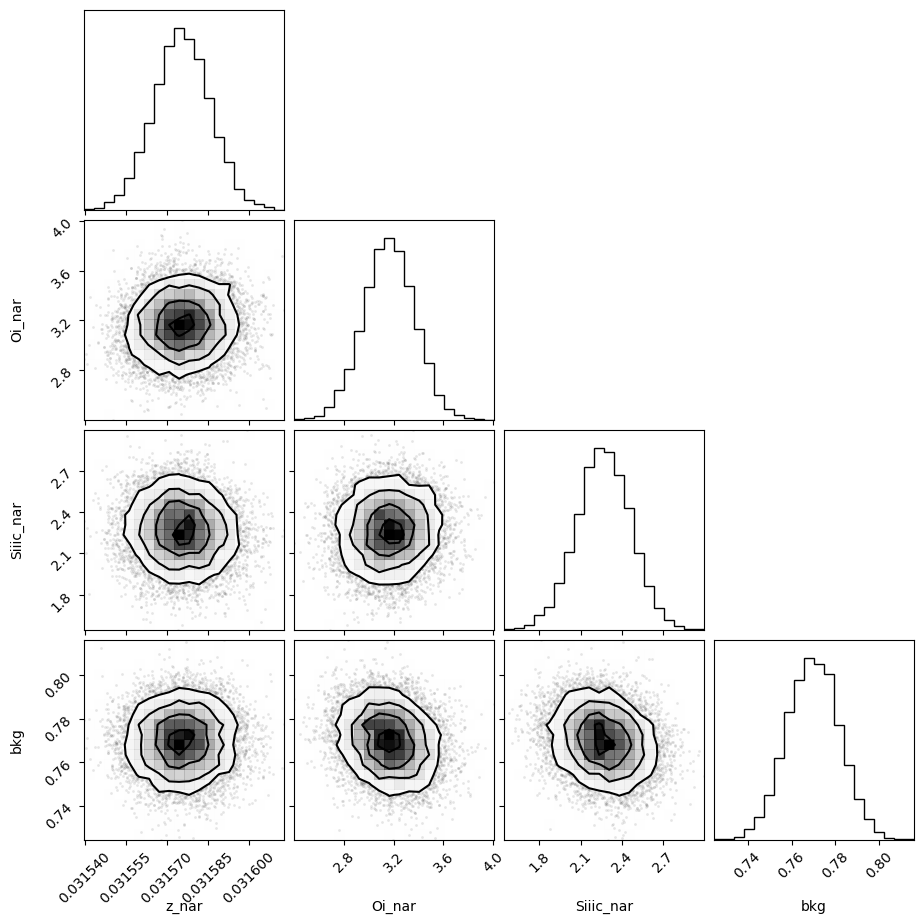

In [115]:
corner.corner(out_oi_siii.flatchain, labels=out_oi_siii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

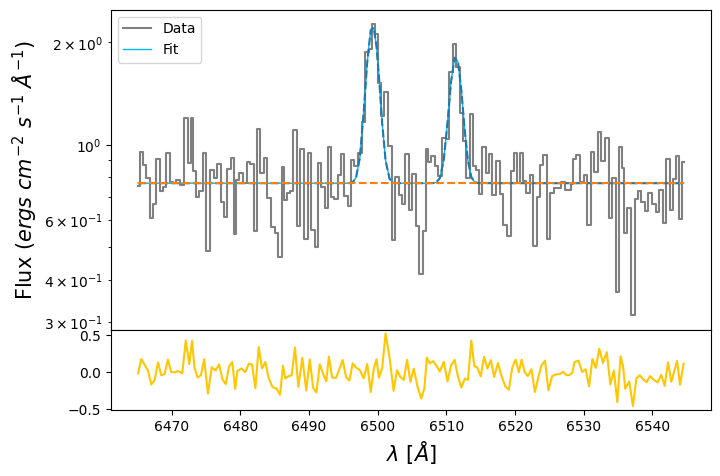

In [116]:
oia_nar_flux = out2_oi_siii.params['Oi_nar'].value
oia_nar_std = out2_oi_siii.params['Oi_nar'].stderr

oia_brd_flux = out2_oi_siii.params['Oi_brd'].value
oia_brd_std = out2_oi_siii.params['Oi_brd'].stderr

siiic_nar_flux = out2_oi_siii.params['Siiic_nar'].value
siiic_nar_std = out2_oi_siii.params['Siiic_nar'].stderr

siiic_brd_flux = out2_oi_siii.params['Siiic_brd'].value
siiic_brd_std = out2_oi_siii.params['Siiic_brd'].stderr

z_oi_siii = out2_oi_siii.params['z_nar'].value
z_oi_siii_std = out2_oi_siii.params['z_nar'].stderr

bkg_oi_siii = out2_oi_siii.params['bkg'].value
bkg_oi_siii_std = out2_oi_siii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oi_siii.wavelength, oi_siii.flux,
            color='gray', label='Data', where='mid')

oia_nar = gaussian(oi_siii.wavelength, oia_nar_flux, wave_cat['[OI]6300'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
oia_brd = gaussian(oi_siii.wavelength, oia_brd_flux, wave_cat['[OI]6300'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, siiic_nar_flux, wave_cat['[SIII]6312'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, siiic_brd_flux, wave_cat['[SIII]6312'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

oia = oia_nar + oia_brd
siiic = siiic_nar + siiic_brd

ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic + oia,
        lw=1, color=c[0], label='Fit')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_nar + oia_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_brd + oia_brd, ls='--')

ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg_oi_siii - siiic - oia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [117]:
# EW
EW_OI_6300_nar = ufloat(oia_nar_flux, oia_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300_brd = ufloat(oia_brd_flux, oia_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300 = (ufloat(oia_nar_flux, oia_nar_std) + ufloat(oia_brd_flux, oia_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

EW_SIII_6312_nar = ufloat(siiic_nar_flux, siiic_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312_brd = ufloat(siiic_brd_flux, siiic_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312 = (ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

# [OIII]5007 + HeI 5015

In [118]:
sigma_arc_5007 = (m * wave_cat['[OIII]5007']*(1 + z_BN[igal])) + n

sigma_nar_5007 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_5007**2))
sigma_brd_5007 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5007**2))

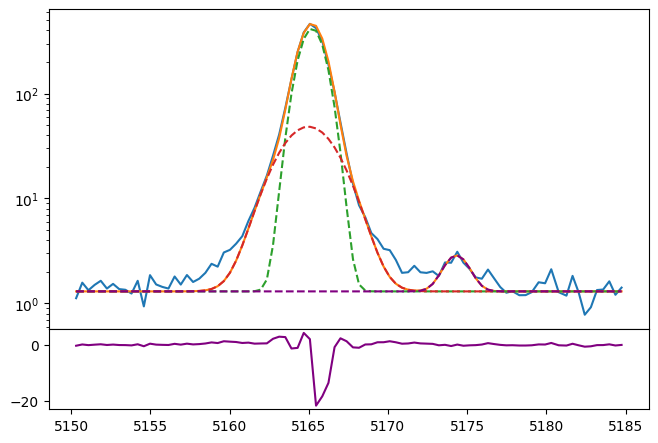

In [119]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hei.wavelength, oiii_hei.flux)
bkg = 1.3

oiiia_nar = gaussian(oiii_hei.wavelength, 8e2, wave_cat['[OIII]5007'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, 2e2, wave_cat['[OIII]5007'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5007))

hei_5015 = gaussian(oiii_hei.wavelength, 3, wave_cat['HeI5015'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))

ax.plot(oiii_hei.wavelength, bkg + oiiia_nar + oiiia_brd + hei_5015)
ax.plot(oiii_hei.wavelength, bkg + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg + hei_5015, ls='--', color='purple')
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg - oiiia_nar - oiiia_brd - hei_5015, color='purple')
ax.set_yscale('log')

In [120]:
params_oiii_hei = Parameters()
params_oiii_hei.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiii_hei.add('z_ratio', value=z_ratio, vary=False)
params_oiii_hei.add('sigma_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oiii_hei.add('sigma_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oiii_hei.add('Hei', value=3, min=0.)
params_oiii_hei.add('Oiiia_nar', value=8.0e2, min=0.)
params_oiii_hei.add('Oiiia_brd', value=2.0e2, min=0.)
params_oiii_hei.add('bkg', value=1.3, min=0.)


def residual_oiii_hei(params_oiii_hei, x, data, uncertainty):
    
    z_nar = params_oiii_hei['z_nar']
    z_brd = params_oiii_hei['z_nar'] * params_oiii_hei['z_ratio']
    sigma_nar = params_oiii_hei['sigma_nar']
    sigma_brd = params_oiii_hei['sigma_brd']
    oiiia_nar = params_oiii_hei['Oiiia_nar']
    oiiia_brd = params_oiii_hei['Oiiia_brd']
    hei = params_oiii_hei['Hei']
    bkg = params_oiii_hei['bkg']
    
    x = oiii_hei.wavelength
    model_oiii = gaussian(x, oiiia_nar, wave_cat['[OIII]5007'], z_nar, sigma_nar) \
               + gaussian(x, oiiia_brd, wave_cat['[OIII]5007'], z_brd, sigma_brd)
    model_hei = gaussian(x, hei, wave_cat['HeI5015'], z_nar, sigma_nar)
    
    return (model_oiii + model_hei + bkg - oiii_hei.flux) / oiii_hei.noise

In [121]:
np.random.seed(1624)
out_oiii_hei = minimize(residual_oiii_hei, params_oiii_hei, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:58<00:00, 42.57it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 55.79075084  78.70448997  82.77308418  91.07470155 112.12291525]


In [122]:
out_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03162453,3.4352e-07,(0.00%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.85897885,,,0.8589788451201229,-inf,inf,False
sigma_brd,1.74182342,,,1.7418234169028375,-inf,inf,False
Hei,1.96142218,0.26591996,(13.56%),3,0.00000000,inf,True
Oiiia_nar,847.324325,2.26438345,(0.27%),800.0,0.00000000,inf,True
Oiiia_brd,127.845525,1.94466268,(1.52%),200.0,0.00000000,inf,True
bkg,1.71274914,0.02760295,(1.61%),1.3,0.00000000,inf,True


In [123]:
np.random.seed(1624)
out2_oiii_hei = minimize(residual_oiii_hei, out_oiii_hei.params, args=(1, 1, 1),
                      method='leastsq')

In [124]:
out2_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03162452,1.8909e-06,(0.01%),0.03162452775375715,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.85897885,0.00000000,(0.00%),0.8589788451201229,-inf,inf,False
sigma_brd,1.74182342,0.00000000,(0.00%),1.7418234169028375,-inf,inf,False
Hei,1.96254168,1.41740315,(72.22%),1.9614221759535224,0.00000000,inf,True
Oiiia_nar,847.325673,12.4118789,(1.46%),847.324325455481,0.00000000,inf,True
Oiiia_brd,127.850122,10.5663427,(8.26%),127.84552545583543,0.00000000,inf,True
bkg,1.71241336,0.14513232,(8.48%),1.7127491353244597,0.00000000,inf,True


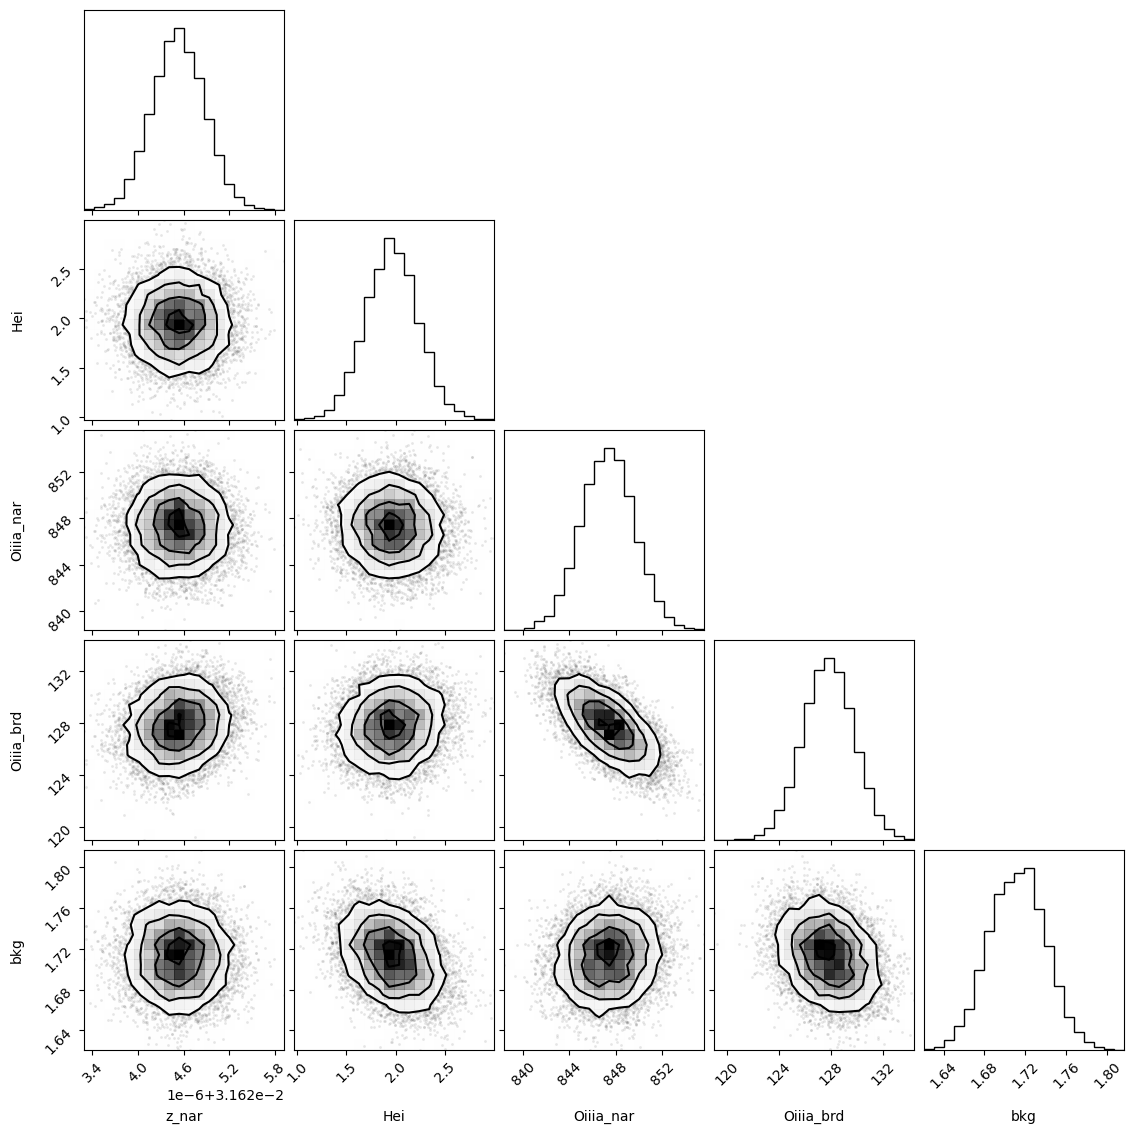

In [125]:
corner.corner(out_oiii_hei.flatchain, labels=out_oiii_hei.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

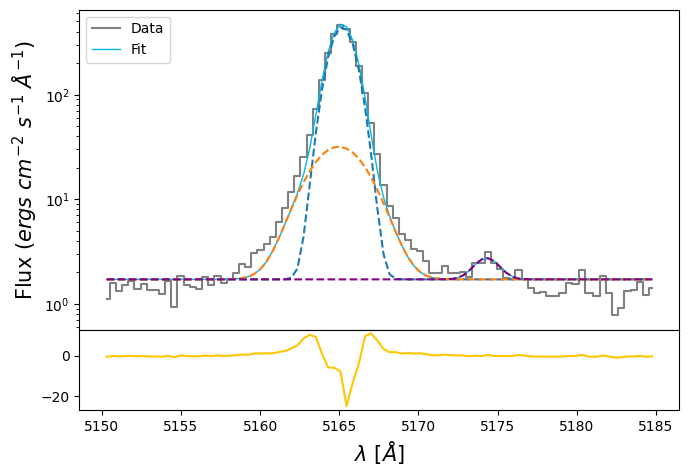

In [126]:
hei_flux = out2_oiii_hei.params['Hei'].value
hei_std = out2_oiii_hei.params['Hei'].stderr

oiiia_nar_flux = out2_oiii_hei.params['Oiiia_nar'].value
oiiia_nar_std = out2_oiii_hei.params['Oiiia_nar'].stderr

oiiia_brd_flux = out2_oiii_hei.params['Oiiia_brd'].value
oiiia_brd_std = out2_oiii_hei.params['Oiiia_brd'].stderr

z_oiii_hei = out2_oiii_hei.params['z_nar'].value
z_oiii_hei_std = out2_oiii_hei.params['z_nar'].stderr

bkg_oiii_hei = out2_oiii_hei.params['bkg'].value
bkg_oiii_hei_std = out2_oiii_hei.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_hei.wavelength, oiii_hei.flux,
            color='gray', label='Data', where='mid')

hei = gaussian(oiii_hei.wavelength, hei_flux, wave_cat['HeI5015'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))

oiiia_nar = gaussian(oiii_hei.wavelength, oiiia_nar_flux, wave_cat['[OIII]5007'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, oiiia_brd_flux, wave_cat['[OIII]5007'], z_oiii_hei * z_ratio, upy.nominal_values(sigma_brd_5007))

oiiia = oiiia_nar + oiiia_brd

ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia + hei,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + hei, ls='--', color='purple')

ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg_oiii_hei - oiiia - hei,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [127]:
# EW
EW_OIII_5007_nar = ufloat(oiiia_nar_flux, oiiia_nar_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007_brd = ufloat(oiiia_brd_flux, oiiia_brd_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007 = (ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)

# [OIII]4363

In [128]:
sigma_arc_4363 = (m * wave_cat['[OIII]4363']*(1 + z_BN[igal])) + n

sigma_nar_4363 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4363**2))
sigma_brd_4363 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4363**2))

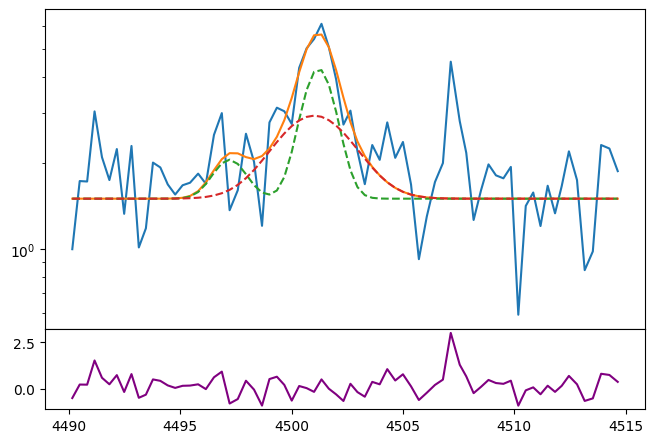

In [129]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4363.wavelength, oiii_4363.flux)
bkg = 1.5

feii_4360 = gaussian(oiii_4363.wavelength, 1.0, wave_cat['[FeII]4360'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, 5.0, wave_cat['[OIII]4363'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, 6.0, wave_cat['[OIII]4363'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4363))

ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + oiiic_brd + feii_4360)
ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, bkg + oiiic_brd, ls='--')
ax1.plot(oiii_4363.wavelength, oiii_4363.flux - bkg - oiiic_nar - oiiic_brd - feii_4360, color='purple')
ax.set_yscale('log')

In [130]:
params_oiiic = Parameters()

params_oiiic.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiiic.add('z_ratio', value=z_ratio, vary=False)
params_oiiic.add('sigma_nar', value=upy.nominal_values(sigma_nar_4363), vary=False)
params_oiiic.add('sigma_brd', value=upy.nominal_values(sigma_brd_4363), vary=False)
params_oiiic.add('Feii_4360_nar', value=1.0, min=0.)
params_oiiic.add('Oiiic_nar', value=5.0, min=0.)
params_oiiic.add('Oiiic_brd', value=6.0, min=0.)
params_oiiic.add('bkg', value=1.5, min=0.)


def residual_oiiic(params_oiiic, x, data, uncertainty):
    
    z_nar = params_oiiic['z_nar']
    z_brd = params_oiiic['z_nar'] * params_oiiic['z_ratio']
    sigma_nar = params_oiiic['sigma_nar']
    sigma_brd = params_oiiic['sigma_brd']
    feii_4360_flux = params_oiiic['Feii_4360_nar']
    oiiic_nar_flux = params_oiiic['Oiiic_nar']
    oiiic_brd_flux = params_oiiic['Oiiic_brd']
    bkg = params_oiiic['bkg']
    
    x = oiii_4363.wavelength
    model = gaussian(x, feii_4360_flux, wave_cat['[FeII]4360'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_nar_flux, wave_cat['[OIII]4363'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_brd_flux, wave_cat['[OIII]4363'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4363.flux) / oiii_4363.noise

In [131]:
np.random.seed(1624)
out_oiiic = minimize(residual_oiiic, params_oiiic, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:53<00:00, 46.94it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [45.98664989 51.54962248 51.37908045 52.64966546 54.50267068]


In [132]:
out_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03161739,1.6711e-05,(0.05%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.72050944,,,0.7205094436607705,-inf,inf,False
sigma_brd,1.67786710,,,1.6778671037098047,-inf,inf,False
Feii_4360_nar,0.62106890,0.38879439,(62.60%),1.0,0.00000000,inf,True
Oiiic_nar,5.43423655,0.88715727,(16.33%),5.0,0.00000000,inf,True
Oiiic_brd,4.16528414,1.40889531,(33.82%),6.0,0.00000000,inf,True
bkg,1.70839457,0.06566099,(3.84%),1.5,0.00000000,inf,True


In [133]:
np.random.seed(1624)
out2_oiiic = minimize(residual_oiiic, out_oiiic.params, args=(1, 1, 1),
                      method='leastsq')

In [134]:
out2_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03161825,1.8558e-05,(0.06%),0.0316173948976116,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.72050944,0.00000000,(0.00%),0.7205094436607705,-inf,inf,False
sigma_brd,1.67786710,0.00000000,(0.00%),1.6778671037098047,-inf,inf,False
Feii_4360_nar,0.57534472,0.47971521,(83.38%),0.6210688977531005,0.00000000,inf,True
Oiiic_nar,5.45747349,0.95162770,(17.44%),5.434236546210389,0.00000000,inf,True
Oiiic_brd,4.16351514,1.51232680,(36.32%),4.165284138157978,0.00000000,inf,True
bkg,1.71180526,0.07174130,(4.19%),1.708394572136541,0.00000000,inf,True


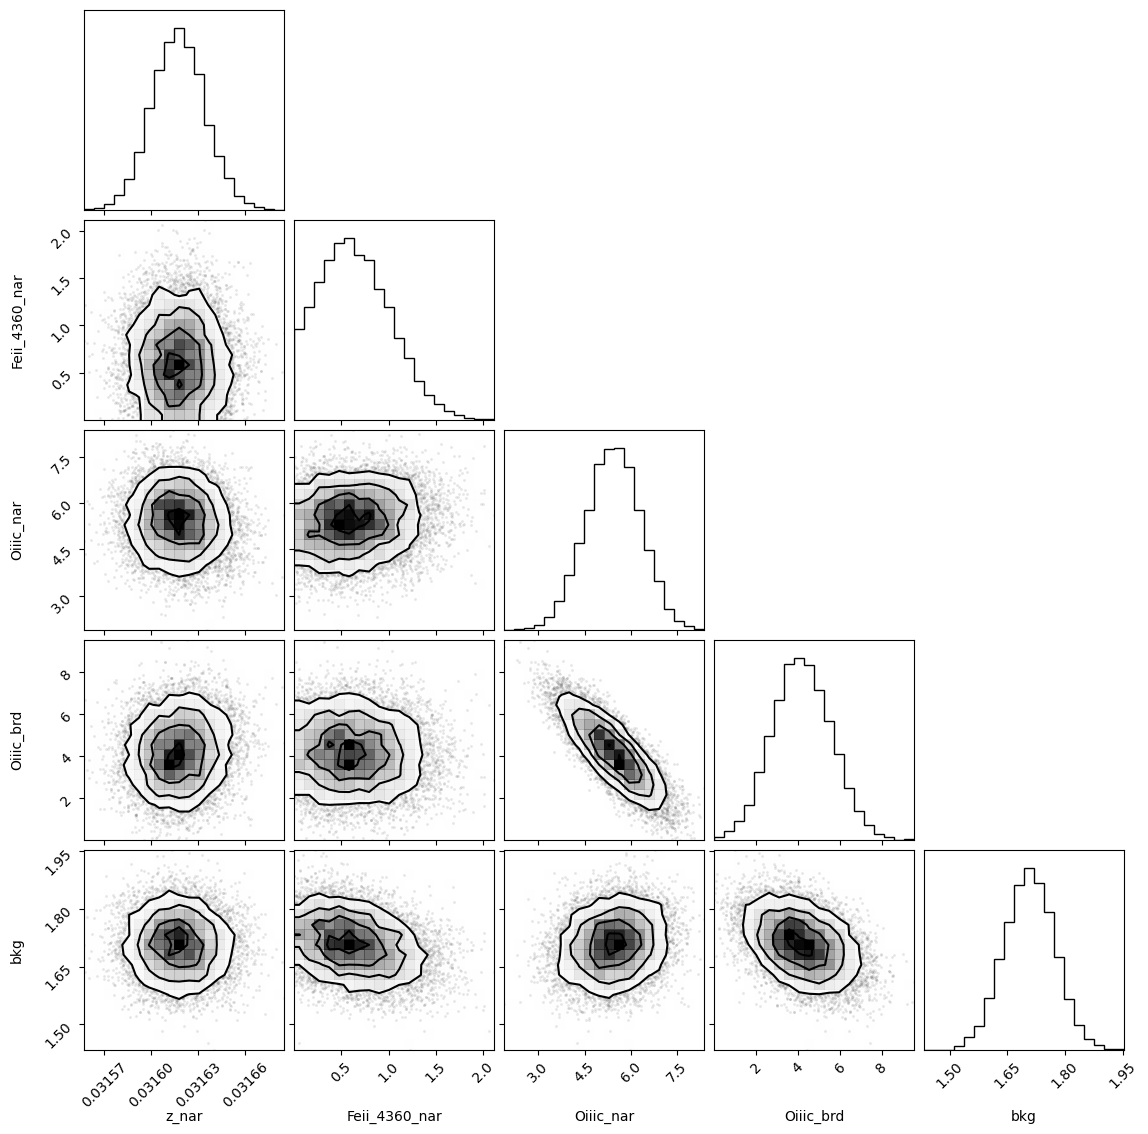

In [135]:
corner.corner(out_oiiic.flatchain, labels=out_oiiic.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

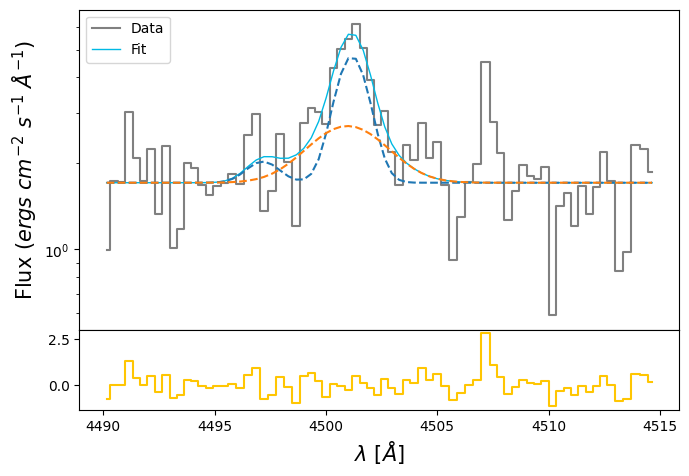

In [136]:
oiiic_nar_flux = out2_oiiic.params['Oiiic_nar'].value
oiiic_nar_std = out2_oiiic.params['Oiiic_nar'].stderr

oiiic_brd_flux = out2_oiiic.params['Oiiic_brd'].value
oiiic_brd_std = out2_oiiic.params['Oiiic_brd'].stderr

feii_4360_flux = out2_oiiic.params['Feii_4360_nar'].value
feii_4360_std = out2_oiiic.params['Feii_4360_nar'].stderr

z_oiii = out2_oiiic.params['z_nar'].value
z_oiii_std = out2_oiiic.params['z_nar'].stderr

bkg_oiiic = out2_oiiic.params['bkg'].value
bkg_oiiic_std = out2_oiiic.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4363.wavelength, oiii_4363.flux,
            color='gray', label='Data', where='mid')

feii_4360 = gaussian(oiii_4363.wavelength, feii_4360_flux, wave_cat['[FeII]4360'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, oiiic_nar_flux, wave_cat['[OIII]4363'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, oiiic_brd_flux, wave_cat['[OIII]4363'], z_oiii * z_ratio, upy.nominal_values(sigma_brd_4363))
oiiic = oiiic_nar + oiiic_brd

ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic + feii_4360, lw=1, color=c[0], label='Fit')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_brd, ls='--')
ax1.step(oiii_4363.wavelength, oiii_4363.flux - bkg_oiiic - oiiic - feii_4360, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [137]:
# EW
EW_OIII_4363_nar = ufloat(oiiic_nar_flux, oiiic_nar_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363_brd = ufloat(oiiic_brd_flux, oiiic_brd_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363 = (ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / ufloat(bkg_oiiic, bkg_oiiic_std)

# [ArIII]7135

In [138]:
sigma_arc_7135 = (m * wave_cat['[ArIII]7135']*(1 + z_BN[igal])) + n

sigma_nar_7135 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7135**2))
sigma_brd_7135 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7135**2))

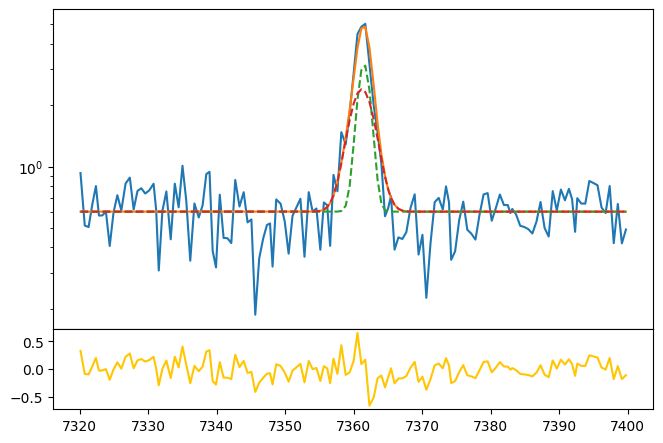

In [139]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ariii_7135.wavelength, ariii_7135.flux)
bkg = 0.6

ariiia_nar = gaussian(ariii_7135.wavelength, 0.6e1, wave_cat['[ArIII]7135'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, 0.8e1, wave_cat['[ArIII]7135'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7135))

ax.plot(ariii_7135.wavelength, bkg + ariiia_nar + ariiia_brd)
ax.plot(ariii_7135.wavelength, bkg + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg + ariiia_brd, ls='--')
ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg - ariiia_nar - ariiia_brd, color=c[3])
ax.set_yscale('log')

In [140]:
params_ariii = Parameters()
params_ariii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ariii.add('z_ratio', value=z_ratio, vary=False)
params_ariii.add('sigma_nar', value=upy.nominal_values(sigma_nar_7135), vary=False)
params_ariii.add('sigma_brd', value=upy.nominal_values(sigma_brd_7135), vary=False)
params_ariii.add('Ariiia_nar', value=0.6e1, min=0.)
params_ariii.add('Ariiia_brd', value=0.8e1, min=0.)
params_ariii.add('bkg', value=0.6, min=0.)


def residual_ariii(params_ariii, x, data, uncertainty):
    
    z_nar = params_ariii['z_nar']
    z_brd = params_ariii['z_nar'] * params_ariii['z_ratio']
    sigma_nar = params_ariii['sigma_nar']
    sigma_brd = params_ariii['sigma_brd']
    ariiia_nar = params_ariii['Ariiia_nar']
    ariiia_brd = params_ariii['Ariiia_brd']
    bkg = params_ariii['bkg']
    
    x = ariii_7135.wavelength
    model_ariii = gaussian(x, ariiia_nar, wave_cat['[ArIII]7135'], z_nar, sigma_nar) \
                + gaussian(x, ariiia_brd, wave_cat['[ArIII]7135'], z_brd, sigma_brd)
    
    return (model_ariii + bkg - ariii_7135.flux) / ariii_7135.noise

In [141]:
np.random.seed(1624)
out_ariii = minimize(residual_ariii, params_ariii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:51<00:00, 48.89it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [40.53220432 50.98817415 48.47988949 38.60258866]


In [142]:
out_ariii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03159949,4.7920e-06,(0.02%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.92492338,,,0.9249233768334361,-inf,inf,False
sigma_brd,1.77527108,,,1.7752710813619823,-inf,inf,False
Ariiia_nar,7.58596814,0.55421729,(7.31%),6.0,0.00000000,inf,True
Ariiia_brd,5.79733150,0.74470299,(12.85%),8.0,0.00000000,inf,True
bkg,0.59663665,0.01183229,(1.98%),0.6,0.00000000,inf,True


In [143]:
np.random.seed(1624)
out2_ariii = minimize(residual_ariii, out_ariii.params, args=(1, 1, 1), method='leastsq')

In [144]:
out2_ariii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03159942,5.5724e-06,(0.02%),0.031599493671938865,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.92492338,0.00000000,(0.00%),0.9249233768334361,-inf,inf,False
sigma_brd,1.77527108,0.00000000,(0.00%),1.7752710813619823,-inf,inf,False
Ariiia_nar,7.61972385,0.65234133,(8.56%),7.585968138573681,0.00000000,inf,True
Ariiia_brd,5.75412380,0.87667523,(15.24%),5.797331502058722,0.00000000,inf,True
bkg,0.59641141,0.01357893,(2.28%),0.5966366456258418,0.00000000,inf,True


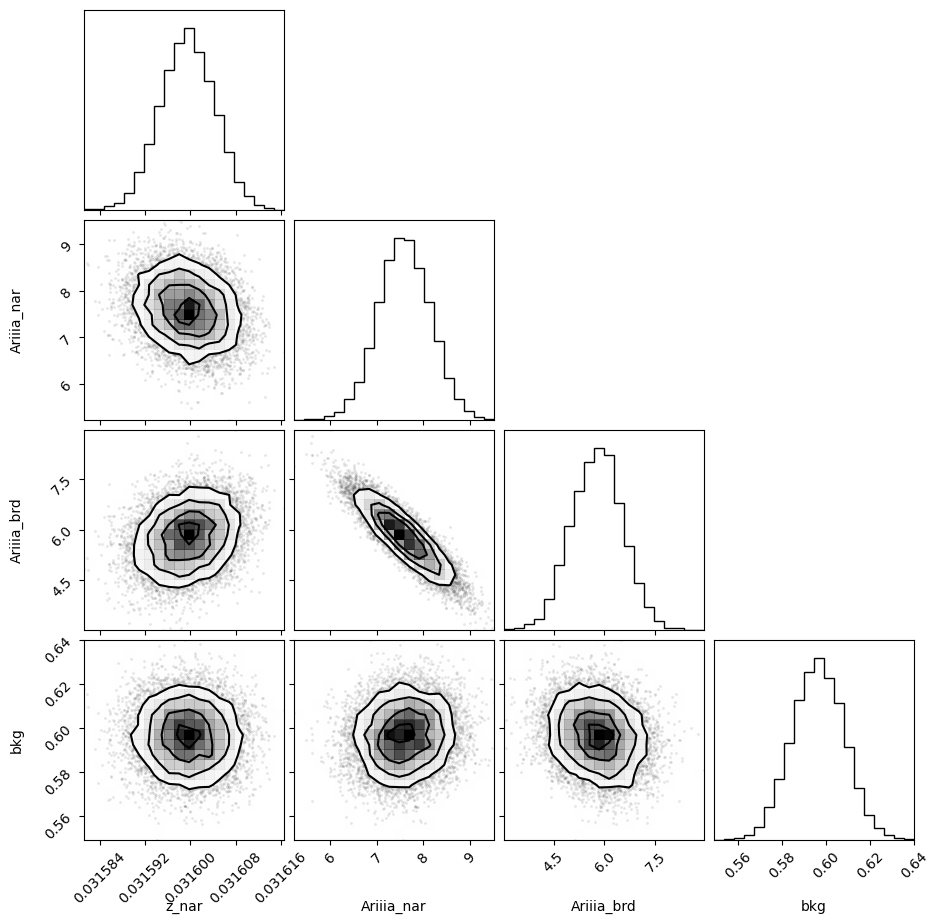

In [145]:
corner.corner(out_ariii.flatchain, labels=out_ariii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

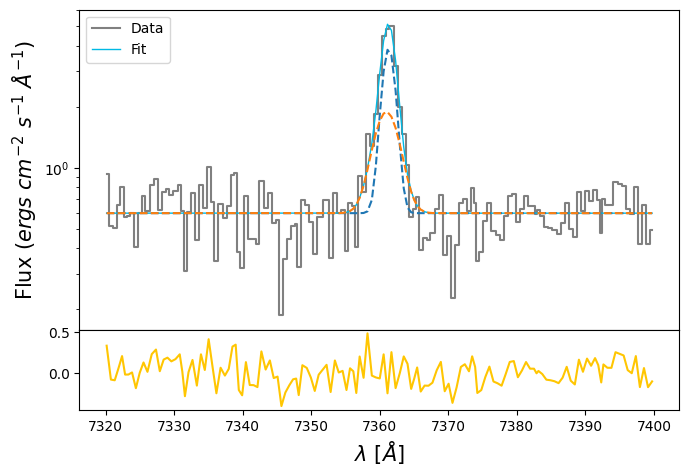

In [146]:
ariiia_nar_flux = out2_ariii.params['Ariiia_nar'].value
ariiia_nar_std = out2_ariii.params['Ariiia_nar'].stderr

ariiia_brd_flux = out2_ariii.params['Ariiia_brd'].value
ariiia_brd_std = out2_ariii.params['Ariiia_brd'].stderr

z_ariii = out2_ariii.params['z_nar'].value
z_ariii_std = out2_ariii.params['z_nar'].stderr

bkg_ariii = out2_ariii.params['bkg'].value
bkg_ariii_std = out2_ariii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ariii_7135.wavelength, ariii_7135.flux,
            color='gray', label='Data', where='mid')

ariiia_nar = gaussian(ariii_7135.wavelength, ariiia_nar_flux, wave_cat['[ArIII]7135'], z_ariii, upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, ariiia_brd_flux, wave_cat['[ArIII]7135'], z_ariii * z_ratio, upy.nominal_values(sigma_brd_7135))

ariiia = ariiia_nar + ariiia_brd

ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia,
        lw=1, color=c[0], label='Fit')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_brd, ls='--')

ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg_ariii - ariiia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [147]:
# EW
EW_ArIII_7135_nar = ufloat(ariiia_nar_flux, ariiia_nar_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135_brd = ufloat(ariiia_brd_flux, ariiia_brd_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135 = (ufloat(ariiia_nar_flux, ariiia_nar_std) + ufloat(ariiia_brd_flux, ariiia_brd_std)) / ufloat(bkg_ariii, bkg_ariii_std)

# [NeIII]3868

In [148]:
sigma_arc_3868 = (m * wave_cat['[NeIII]3868']*(1 + z_BN[igal])) + n

sigma_nar_3868 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_3868**2))
sigma_brd_3868 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3868**2))

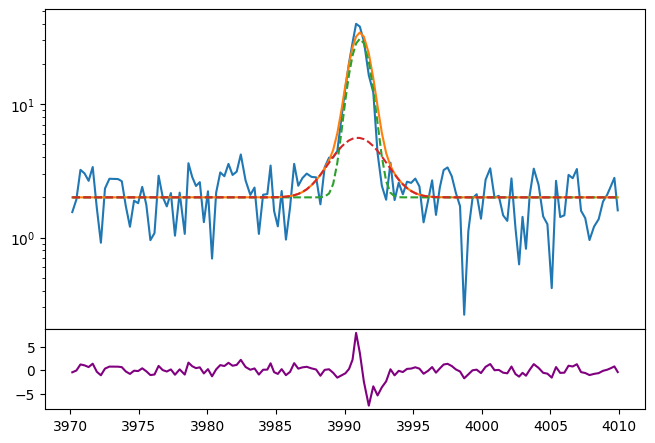

In [149]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(neiii_3868.wavelength, neiii_3868.flux)
bkg = 2

neiiia_nar = gaussian(neiii_3868.wavelength, 5e1, wave_cat['[NeIII]3868'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, 1.5e1, wave_cat['[NeIII]3868'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3868))

ax.plot(neiii_3868.wavelength, bkg + neiiia_nar + neiiia_brd)
ax.plot(neiii_3868.wavelength, bkg + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg + neiiia_brd, ls='--')
ax1.plot(neiii_3868.wavelength, neiii_3868.flux - bkg - neiiia_nar - neiiia_brd, color='purple')
ax.set_yscale('log')

In [150]:
params_neiii_3868 = Parameters()
params_neiii_3868.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_neiii_3868.add('z_ratio', value=z_ratio, vary=False)
params_neiii_3868.add('sigma_nar', value=upy.nominal_values(sigma_nar_3868), vary=False)
params_neiii_3868.add('sigma_brd', value=upy.nominal_values(sigma_brd_3868), vary=False)
params_neiii_3868.add('Neiiia_nar', value=5e1, min=0.)
params_neiii_3868.add('Neiiia_brd', value=0., vary=False)
params_neiii_3868.add('bkg', value=2, min=0.)


def residual_neiii_3868(params_neiii_3868, x, data, uncertainty):
    
    z_nar = params_neiii_3868['z_nar']
    z_brd = params_neiii_3868['z_nar'] * params_neiii_3868['z_ratio']
    sigma_nar = params_neiii_3868['sigma_nar']
    sigma_brd = params_neiii_3868['sigma_brd']
    neiiia_nar_flux = params_neiii_3868['Neiiia_nar']
    neiiia_brd_flux = params_neiii_3868['Neiiia_brd']
    bkg = params_neiii_3868['bkg']
    
    x = neiii_3868.wavelength
    model = gaussian(x, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_nar, sigma_nar) + \
            gaussian(x, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_brd, sigma_brd)
    
    return (model + bkg - neiii_3868.flux) / neiii_3868.noise

In [151]:
np.random.seed(1624)
out_neiii_3868 = minimize(residual_neiii_3868, params_neiii_3868, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:49<00:00, 50.73it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [30.59500835 55.25992983 40.45539334]


In [152]:
out_neiii_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03159395,3.4519e-06,(0.01%),0.031629020585252,-inf,inf,True
z_ratio,0.99858792,,,0.9985879189080148,-inf,inf,False
sigma_nar,0.69063061,,,0.6906306147990701,-inf,inf,False
sigma_brd,1.66525518,,,1.6652551772641082,-inf,inf,False
Neiiia_nar,56.8608112,0.97940608,(1.72%),50.0,0.00000000,inf,True
Neiiia_brd,0.00000000,,,0.0,-inf,inf,False
bkg,2.10675097,0.06828847,(3.24%),2,0.00000000,inf,True


In [153]:
np.random.seed(1624)
out2_neiii_3868 = minimize(residual_neiii_3868, out_neiii_3868.params, args=(1, 1, 1), method='leastsq')

In [154]:
out2_neiii_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.03159401,4.5924e-06,(0.01%),0.03159394745586122,-inf,inf,True
z_ratio,0.99858792,0.00000000,(0.00%),0.9985879189080148,-inf,inf,False
sigma_nar,0.69063061,0.00000000,(0.00%),0.6906306147990701,-inf,inf,False
sigma_brd,1.66525518,0.00000000,(0.00%),1.6652551772641082,-inf,inf,False
Neiiia_nar,56.8779056,1.21862956,(2.14%),56.860811207321916,0.00000000,inf,True
Neiiia_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,2.10838606,0.08465264,(4.02%),2.1067509747214643,0.00000000,inf,True


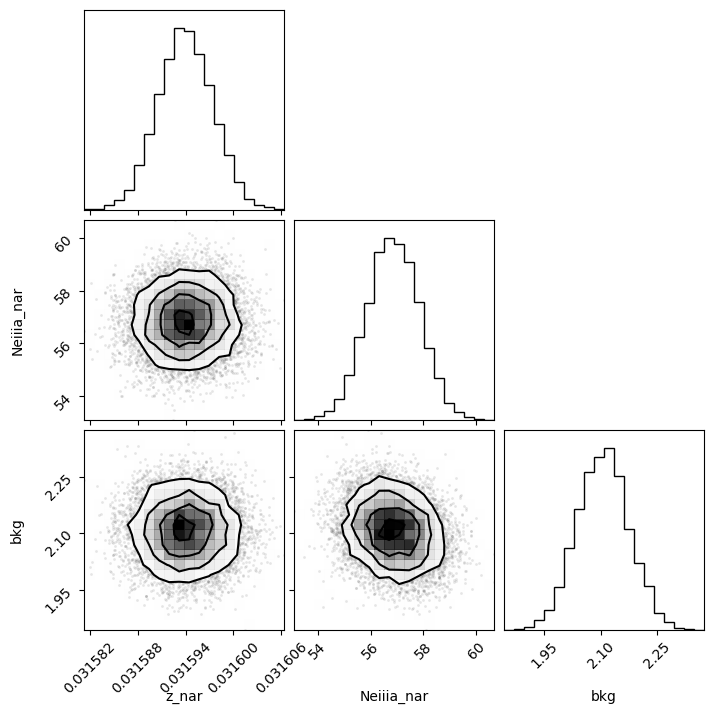

In [155]:
corner.corner(out_neiii_3868.flatchain, labels=out_neiii_3868.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

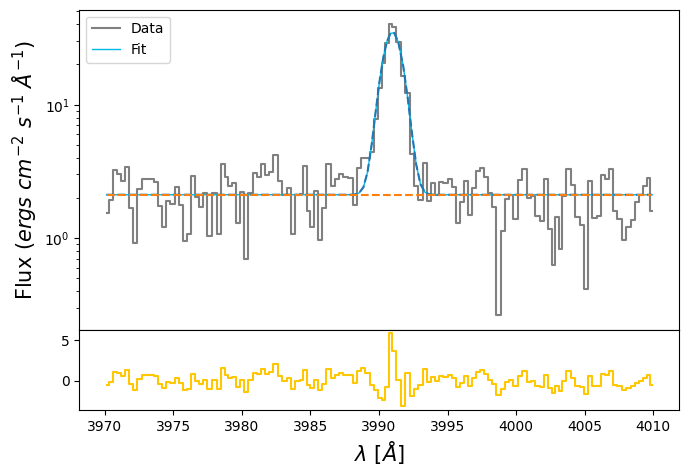

In [156]:
neiiia_nar_flux = out2_neiii_3868.params['Neiiia_nar'].value
neiiia_nar_std = out2_neiii_3868.params['Neiiia_nar'].stderr

neiiia_brd_flux = out2_neiii_3868.params['Neiiia_brd'].value
neiiia_brd_std = out2_neiii_3868.params['Neiiia_brd'].stderr

z_neiii = out2_neiii_3868.params['z_nar'].value
z_neiii_std = out2_neiii_3868.params['z_nar'].stderr

bkg_neiiia = out2_neiii_3868.params['bkg'].value
bkg_neiiia_std = out2_neiii_3868.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(neiii_3868.wavelength, neiii_3868.flux,
            color='gray', label='Data', where='mid')

neiiia_nar = gaussian(neiii_3868.wavelength, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_neiii, upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_neiii * z_ratio, upy.nominal_values(sigma_brd_3868))
neiiia = neiiia_nar + neiiia_brd

ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia, lw=1, color=c[0], label='Fit')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_brd, ls='--')
ax1.step(neiii_3868.wavelength, neiii_3868.flux - bkg_neiiia - neiiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [157]:
# EW
EW_NeIII_3868_nar = ufloat(neiiia_nar_flux, neiiia_nar_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868_brd = ufloat(neiiia_brd_flux, neiiia_brd_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868 = (ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / ufloat(bkg_neiiia, bkg_neiiia_std)

# Balmer decrements

In [158]:
from magE.functions import *
from magE.functions import calzetti2000 as k_cal

flux_ha_bal = ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)
flux_hb_bal = ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)
flux_hg_bal = ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)
flux_hd_bal = ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)

y_balmer = upy.log10([(flux_ha_bal / flux_hb_bal) / 2.86, 
                    (flux_hb_bal / flux_hb_bal) / 1.0,
                    (flux_hg_bal / flux_hb_bal) / 0.464,
                    (flux_hd_bal / flux_hb_bal) / 0.256])

x_balmer = np.array([k_cal(wave_cat['Ha']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hb']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hg']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hd']) - k_cal(wave_cat['Hb'])])

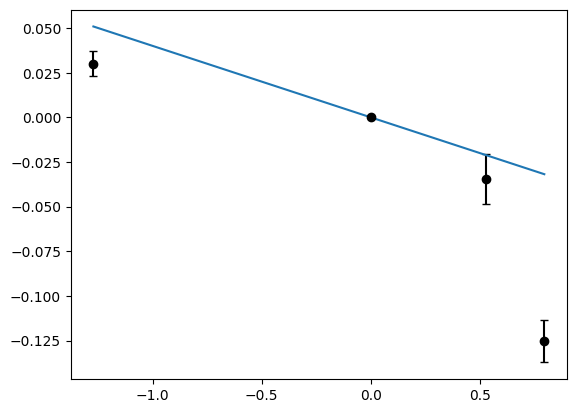

In [159]:
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, x_balmer * (-0.4 * 0.1))

In [160]:
params_balmer = Parameters()
params_balmer.add('slope', value=0.4 * 0.1)

def residuals_balmer(params_balmer, x, data, uncertainty):
    
    slope = params_balmer['slope']
    x = x_balmer
    
    model = x * (-slope)
    return (model - upy.nominal_values(y_balmer)) / np.max(upy.std_devs(y_balmer))

np.random.seed(1624)
out_balmer = minimize(residuals_balmer, params_balmer, args=(1, 1, 1),
                      method='leastsq')

In [161]:
out_balmer.params

name,value,standard error,relative error,initial value,min,max,vary
slope,0.06178927,0.03275404,(53.01%),0.04000000000000001,-inf,inf,True


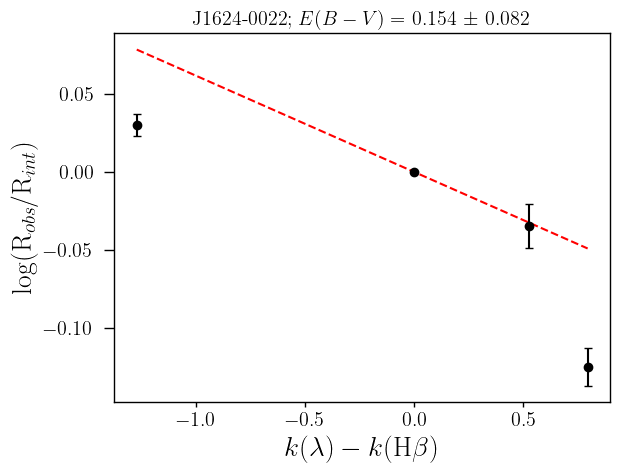

In [162]:
color_excess = ufloat(out_balmer.params['slope'].value, out_balmer.params['slope'].stderr) / 0.4
E_BV = out_balmer.params['slope'].value / 0.4

texPlot('on')
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, - E_BV * 0.4 * x_balmer, ls='--', color='red')
plt.ylabel(r'log(R$_{obs}$/R$_{int}$)')
plt.xlabel(r'$k(\lambda) - k($H$\beta)$')
plt.title(r'J1624-0022; $E(B-V) = $ '+str(round(color_excess.nominal_value, 3))+' $\pm$ '+str(round(color_excess.std_dev, 3)))
plt.savefig('/home/benjamin/Documents/analogs/results/balmer_decrements/bal_dec_lstsq_J1624.pdf', bbox_inches='tight')

In [163]:
decrement_dict = {'galname': galname,
                 'Ha/Hb': (flux_ha_bal / flux_hb_bal).nominal_value,
                 'Ha/Hb_err': (flux_ha_bal / flux_hb_bal).std_dev,
                 'Hg/Hb': (flux_hg_bal / flux_hb_bal).nominal_value,
                 'Hg/Hb_err': (flux_hg_bal / flux_hb_bal).std_dev,
                 'Hd/Hb': (flux_hd_bal / flux_hb_bal).nominal_value,
                 'Hd/Hb_err': (flux_hd_bal / flux_hb_bal).std_dev,
                 'E_BV': out_balmer.params['slope'].value / 0.4,
                 'E_BV_err': out_balmer.params['slope'].stderr / 0.4
                 }
decrement_dict_pd = pd.DataFrame(data=decrement_dict, index=[0])
save_catalog(galname, decrement_dict_pd, magePath + '/results/bal_decrements_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1624, overwriting...
Done.


# Dust correction

In [164]:
oiid_tot_flux = ((ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]3726']))
oiic_tot_flux = ((ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]3729']))

neiiia_tot_flux = ((ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[NeIII]3868']))

hd_tot_flux = ((ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Hd']))

hg_tot_flux = ((ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Hg']))

oiiic_tot_flux = ((ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OIII]4363']))

heid_tot_flux = None

feiiia_tot_flux = None

heiia_tot_flux = None

ariva_tot_flux = None

hb_tot_flux = ((ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Hb']))

oiiib_tot_flux = ((ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OIII]4959']))

oiiia_tot_flux = ((ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OIII]5007']))

niic_tot_flux = None

heic_tot_flux = None

oia_tot_flux = ((ufloat(oia_nar_flux, oia_nar_std) + ufloat(oia_brd_flux, oia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OI]6300']))

siiic_tot_flux = ((ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SIII]6312']))

niib_tot_flux = ((ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[NII]6548']))

ha_tot_flux = ((ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Ha']))

niia_tot_flux = ((ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[NII]6584']))

heib_tot_flux = None

siib_tot_flux = ((ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SII]6716']))
siia_tot_flux = ((ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SII]6730']))

heia_tot_flux = None

ariiia_tot_flux = ((ufloat(ariiia_nar_flux, ariiia_nar_std) + ufloat(ariiia_brd_flux, ariiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[ArIII]7135']))

oiib_tot_flux = ((ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]7319']))
oiia_tot_flux = ((ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]7330']))

siiib_tot_flux = ((ufloat(siiib_nar_flux, siiib_nar_std) + ufloat(siiib_brd_flux, siiib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SIII]9069']))

siiia_tot_flux = ((ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SIII]9532']))

# Save data

In [165]:
lines_dict = {'galname': galname,
              '[OII]3726': oiid_tot_flux.nominal_value,
              '[OII]3726_err': oiid_tot_flux.std_dev,
              
              '[OII]3729': oiic_tot_flux.nominal_value,
              '[OII]3729_err': oiic_tot_flux.std_dev,
              
              '[NeIII]3868': neiiia_tot_flux.nominal_value,
              '[NeIII]3868_err': neiiia_tot_flux.std_dev,
              
              'Hd': hd_tot_flux.nominal_value,
              'Hd_err': hd_tot_flux.std_dev,
              
              'Hg': hg_tot_flux.nominal_value,
              'Hg_err': hg_tot_flux.std_dev,
              
              '[OIII]4363': oiiic_tot_flux.nominal_value,
              '[OIII]4363_err': oiiic_tot_flux.std_dev,
              
              'HeI4471': None,
              'HeI4471_err': None,
              
              '[FeIII]4658': None,
              '[FeIII]4658_err': None,
              
              'HeII4686': None,
              'HeII4686_err': None,
              
              '[ArIV]4740': None,
              '[ArIV]4740_err': None,
              
              'Hb': hb_tot_flux.nominal_value,
              'Hb_err': hb_tot_flux.std_dev,
              
              '[OIII]4959': oiiib_tot_flux.nominal_value,
              '[OIII]4959_err': oiiib_tot_flux.std_dev,
              
              '[OIII]5007': oiiia_tot_flux.nominal_value,
              '[OIII]5007_err': oiiia_tot_flux.std_dev,
              
              '[NII]5755': None,
              '[NII]5755_err': None,
              
              'HeI5875': None,
              'HeI5875_err': None,
              
              '[OI]6300': oia_tot_flux.nominal_value,
              '[OI]6300_err': oia_tot_flux.std_dev,
              
              '[SIII]6312': siiic_tot_flux.nominal_value,
              '[SIII]6312_err': siiic_tot_flux.std_dev,
              
              '[NII]6548': niib_tot_flux.nominal_value,
              '[NII]6548_err': niib_tot_flux.std_dev,
              
              'Ha': ha_tot_flux.nominal_value,
              'Ha_err': ha_tot_flux.std_dev,
              
              '[NII]6584': niia_tot_flux.nominal_value,
              '[NII]6584_err': niia_tot_flux.std_dev,
              
              'HeI6678': None,
              'HeI6678_err': None,
              
              '[SII]6716': siib_tot_flux.nominal_value,
              '[SII]6716_err': siib_tot_flux.std_dev,
              
              '[SII]6730': siia_tot_flux.nominal_value,
              '[SII]6730_err': siia_tot_flux.std_dev,
              
              'HeI7065': None,
              'HeI7065_err': None,
              
              '[ArIII]7135': ariiia_tot_flux.nominal_value,
              '[ArIII]7135_err': ariiia_tot_flux.std_dev,
              
              '[OII]7319': oiib_tot_flux.nominal_value,
              '[OII]7319_err': oiib_tot_flux.std_dev,
              
              '[OII]7330': oiia_tot_flux.nominal_value,
              '[OII]7330_err': oiia_tot_flux.std_dev,
              
              '[SIII]9069': siiib_tot_flux.nominal_value,
              '[SIII]9069_err': siiib_tot_flux.std_dev,
              
              '[SIII]9532': siiia_tot_flux.nominal_value,
              '[SIII]9532_err': siiia_tot_flux.std_dev
}
lines_dict_pd = pd.DataFrame(data=lines_dict, index=[0])
save_catalog(galname, lines_dict_pd, magePath + '/results/em_lines_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1624, overwriting...
Done.


In [166]:
ew_dict = {'galname': galname,
              '[OII]3726': EW_OII_3726.nominal_value,
              '[OII]3726_err': EW_OII_3726.std_dev,
              
              '[OII]3729': EW_OII_3729.nominal_value,
              '[OII]3729_err': EW_OII_3729.std_dev,
              
              '[NeIII]3868': EW_NeIII_3868.nominal_value,
              '[NeIII]3868_err': EW_NeIII_3868.std_dev,
              
              'Hd': EW_Hd.nominal_value,
              'Hd_err': EW_Hd.std_dev,
              
              'Hg': EW_Hg.nominal_value,
              'Hg_err': EW_Hg.std_dev,
              
              '[OIII]4363': EW_OIII_4363.nominal_value,
              '[OIII]4363_err': EW_OIII_4363.std_dev,
              
              'HeI4471': None,
              'HeI4471_err': None,
              
              '[FeIII]4658': None,
              '[FeIII]4658_err': None,
              
              'HeII4686': None,
              'HeII4686_err': None,
           
              '[ArIV]4740': None,
              '[ArIV]4740_err': None,
              
              'Hb': EW_Hb.nominal_value,
              'Hb_err': EW_Hb.std_dev,
              
              '[OIII]4959': EW_OIII_4959.nominal_value,
              '[OIII]4959_err': EW_OIII_4959.std_dev,
              
              '[OIII]5007': EW_OIII_5007.nominal_value,
              '[OIII]5007_err': EW_OIII_5007.std_dev,
              
              '[NII]5755': None,
              '[NII]5755_err': None,
              
              'HeI5875': None,
              'HeI5875_err': None,
              
              '[OI]6300': EW_OI_6300.nominal_value,
              '[OI]6300_err': EW_OI_6300.std_dev,
              
              '[SIII]6312': EW_SIII_6312.nominal_value,
              '[SIII]6312_err': EW_SIII_6312.std_dev,
              
              '[NII]6548': EW_NII_6548.nominal_value,
              '[NII]6548_err': EW_NII_6548.std_dev,
              
              'Ha': EW_Ha.nominal_value,
              'Ha_err': EW_Ha.std_dev,
              
              '[NII]6584': EW_NII_6584.nominal_value,
              '[NII]6584_err': EW_NII_6584.std_dev,
              
              'HeI6678': None,
              'HeI6678_err': None,
              
              '[SII]6716': EW_SII_6716.nominal_value,
              '[SII]6716_err': EW_SII_6716.std_dev,
              
              '[SII]6730': EW_SII_6730.nominal_value,
              '[SII]6730_err': EW_SII_6730.std_dev,
              
              'HeI7065': None,
              'HeI7065_err': None,
              
              '[ArIII]7135': EW_ArIII_7135.nominal_value,
              '[ArIII]7135_err': EW_ArIII_7135.std_dev,
              
              '[OII]7319': EW_OII_7319.nominal_value,
              '[OII]7319_err': EW_OII_7319.std_dev,
              
              '[OII]7330': EW_OII_7330.nominal_value,
              '[OII]7330_err': EW_OII_7330.std_dev,
              
              '[SIII]9069': EW_SIII_9069.nominal_value,
              '[SIII]9069_err': EW_SIII_9069.std_dev,
              
              '[SIII]9532': EW_SIII_9532.nominal_value,
              '[SIII]9532_err': EW_SIII_9532.std_dev
}
ew_dict_pd = pd.DataFrame(data=ew_dict, index=[0])
save_catalog(galname, ew_dict_pd, magePath + '/results/ew_lines_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1624, overwriting...
Done.


# Temperatures and Densities

In [167]:
# High ionization temperature T[OIII]
T_OIII = TO3(oiiia_tot_flux, oiiib_tot_flux, oiiic_tot_flux)
O2plus_H = 10**(double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII) - 12)

In [168]:
T_OIII

1.1580906218596567+/-0.07831073567067874

In [169]:
# Density n([SII])
el_density = ne(siia_tot_flux, siib_tot_flux, T_OIII)

In [170]:
el_density

119.28690283076861+/-81.11198479385834

In [171]:
# Low ionization temperature T[OII]
IO2_R = 9.36 * (T_OIII**0.44) * O2plus_H * hb_tot_flux
T_OII = TO2(oiia_tot_flux, oiib_tot_flux, oiic_tot_flux, oiid_tot_flux, el_density, IO2_R)

# Garnett
T_OII_G92 = ((0.7 * (T_OIII * 10)) + 0.3) / 10

# This work
T_OII_tw = (slope_o3o2 * T_OIII) + intercept_o3o2

In [172]:
T_OII

0.9173674419454284+/-0.11653372742216365

In [173]:
# Intermediate ionization temperature
T_SIII = TS3(siiia_tot_flux, siiib_tot_flux, siiic_tot_flux)

In [174]:
T_SIII

1.30880924006997+/-0.12263441049991336

In [175]:
# PyNeb T[NII]
#import pyneb as pn
#N2 = pn.Atom('N', 2)
#R_N2 = (niia_tot_flux + niib_tot_flux) / niic_tot_flux
#t_NII = N2.getTemDen(np.random.normal(loc=R_N2.nominal_value, scale=R_N2.std_dev, size=(1000)),
#                         den=el_density.nominal_value, to_eval = "(L(6584) + L(6548)) / L(5755)") / 10000
#T_NII = ufloat(np.mean(t_NII), np.std(t_NII))

In [176]:
temden_dict = {'galname': galname,
               'tOIII': T_OIII.nominal_value,
               'tOIII_err': T_OIII.std_dev,
               'tOII': T_OII.nominal_value,
               'tOII_err': T_OII.std_dev,
               'ne': el_density.nominal_value,
               'ne_err': el_density.std_dev,
               'tNII': None,
               'tNII_err': None,
               'tSIII': T_SIII.nominal_value,
               'tSIII_err': T_SIII.std_dev,
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_measured_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1624, overwriting...
Done.


In [177]:
temden_dict = {'galname': galname,
               'tOIII': T_OIII.nominal_value,
               'tOIII_err': T_OIII.std_dev,
               'tOII': T_OII.nominal_value,
               'tOII_err': T_OII.std_dev,
               'tOII_G92': T_OII_G92.nominal_value,
               'tOII_G92_err': T_OII_G92.std_dev,
               'tOII_tw': T_OII_tw.nominal_value,
               'tOII_tw_err': T_OII_tw.std_dev
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_estimated_lstsq_v2.csv')

Existent catalog (.csv) file.
Existent data for J1624, overwriting...
Done.


# Abundances

In [178]:
# OXYGEN MEASURED

log_Oplus_H_tot = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII, el_density)

log_O2plus_H_tot = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)

O2plus_H_tot = 10**(log_O2plus_H_tot - 12)
Oplus_H_tot = 10**(log_Oplus_H_tot - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tot = (O2plus_H_tot + Oplus_H_tot) #* ICF_Oxygen
log_OH_tot = upy.log10(O_H_tot) + 12

In [179]:
# OXYGEN GARNETT

log_O2plus_H_G92 = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)
log_Oplus_H_G92 = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII_G92, el_density)

O2plus_H_G92 = 10**(log_O2plus_H_G92 - 12)
Oplus_H_G92 = 10**(log_Oplus_H_G92 - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_G92 = (O2plus_H_G92 + Oplus_H_G92) #* ICF_Oxygen
log_OH_G92 = upy.log10(O_H_G92) + 12

In [180]:
# OXYGEN THIS WORK

log_O2plus_H_tw = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)
log_Oplus_H_tw = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII_tw, el_density)

O2plus_H_tw = 10**(log_O2plus_H_tw - 12)
Oplus_H_tw = 10**(log_Oplus_H_tw - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tw = (O2plus_H_tw + Oplus_H_tw) #* ICF_Oxygen
log_OH_tw = upy.log10(O_H_tw) + 12

In [181]:
# SULFUR

log_Splus_H_tot = single_log_S(siia_tot_flux, siib_tot_flux, hb_tot_flux, T_OII)
log_S2plus_H_tot = double_log_S(siiia_tot_flux, siiib_tot_flux, hb_tot_flux, T_SIII)

S2plus_H_tot = 10**(log_S2plus_H_tot - 12)
Splus_H_tot = 10**(log_Splus_H_tot - 12)

ICF_Sulfur = ICF_S(O2plus_H_tot, Oplus_H_tot, alpha=3.27)

S_H_tot = (S2plus_H_tot + Splus_H_tot) * ICF_Sulfur
log_SH_tot = upy.log10(S_H_tot) + 12

In [182]:
# NITROGEN

log_Nplus_H_tot = log_NH_12(niia_tot_flux, niib_tot_flux, hb_tot_flux, T_OII)

Nplus_H_tot = 10**(log_Nplus_H_tot - 12)

ICF_Nitrogen = O_H_tot / Oplus_H_tot 

N_H_tot = Nplus_H_tot * ICF_Nitrogen
log_NH_tot = upy.log10(N_H_tot) + 12

In [183]:
# Nitrogen-to-Oxygen ratio

log_NO_tot = log_NO(niia_tot_flux, oiic_tot_flux, oiid_tot_flux, T_OII)

In [184]:
# NEON

log_Ne2plus_H_tot = log_Ne_12(neiiia_tot_flux, hb_tot_flux, T_OIII)

Ne2plus_H_tot = 10**(log_Ne2plus_H_tot - 12)

ICF_Neon = ICF_Ne(O2plus_H_tot, Oplus_H_tot)

Ne_H_tot = Ne2plus_H_tot * ICF_Neon
log_NeH_tot = upy.log10(Ne_H_tot) + 12

In [185]:
# ARGON

log_Ar2plus_H_tot = double_log_Ar(ariiia_tot_flux, hb_tot_flux, T_SIII)

Ar2plus_H_tot = 10**(log_Ar2plus_H_tot - 12)

ICF_Argon = ICF_double_Ar(O2plus_H_tot, Oplus_H_tot)

Ar_H_tot = Ar2plus_H_tot * ICF_Argon
log_ArH_tot = upy.log10(Ar_H_tot) + 12

In [186]:
# IRON

#log_Fe2plus_H_tot = log_Fe_12(feiiia_tot_flux, hb_tot_flux, T_OIII)
#
#Fe2plus_H_tot = 10**(log_Fe2plus_H_tot - 12)
#
#ICF_Iron = ICF_Fe(O2plus_H_tot, Oplus_H_tot)
#
#Fe_H_tot = Fe2plus_H_tot * ICF_Iron
#log_FeH_tot = upy.log10(Fe_H_tot) + 12

In [187]:
# ionization parameter

q = log_q(oiiia_tot_flux, oiid_tot_flux, log_OH_tot)
U = log_q(oiiia_tot_flux, oiid_tot_flux, log_OH_tot, U=True)

In [188]:
abundance_dict = {'galname': galname,
                  'He/H': None,
                  'He/H_err': None,
                  'log_OH': log_OH_tot.nominal_value,
                  'log_OH_err': log_OH_tot.std_dev,
                  'log_SH': log_SH_tot.nominal_value,
                  'log_SH_err': log_SH_tot.std_dev,
                  'log_NH': log_NH_tot.nominal_value,
                  'log_NH_err': log_NH_tot.std_dev,
                  'log_NO': log_NO_tot.nominal_value,
                  'log_NO_err': log_NO_tot.std_dev,
                  'log_NeH': log_NeH_tot.nominal_value,
                  'log_NeH_err': log_NeH_tot.std_dev,
                  'log_ArH': log_ArH_tot.nominal_value,
                  'log_ArH_err': log_ArH_tot.std_dev,
                  'log_FeH': None,
                  'log_FeH_err': None,
                  'log_q': q.nominal_value,
                  'log_q_err': q.std_dev,
                  'log_U': float(upy.nominal_values(U)),
                  'log_U_err': float(upy.std_devs(U))
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_measured_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J1624, overwriting...
Done.


In [189]:
abundance_dict = {'galname': galname,
                  'log_OH_G92': log_OH_G92.nominal_value,
                  'log_OH_G92_err': log_OH_G92.std_dev,
                  'log_OH_tw': log_OH_tw.nominal_value,
                  'log_OH_tw_err': log_OH_tw.std_dev
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_estimated_lstsq_v2.csv')

Existent catalog (.csv) file.
Existent data for J1624, overwriting...
Done.
